In [1]:
import pandas as pd

import config

In [2]:
from framework.data.data_loader import DataLoader

data_loader = DataLoader()

try:
    df = data_loader.load_data_from_disk(symbol="BTC/USDT", timeframe=config.TIMEFRAME, suffix="_raw")

except ValueError:
    df = data_loader.fetch_historical_data(symbol="BTC/USDT", timeframe=config.TIMEFRAME, days=365 * 3)
    data_loader.save_to_csv(df, symbol="BTC/USDT", timeframe=config.TIMEFRAME, suffix="_raw")

print(f"Data Rows: {len(df)}, Columns: {', '.join(df.columns)}")

Loading data from disk: framework/data/BTC_USDT_5m_raw.csv...
Data Rows: 315344, Columns: open, high, low, close, volume


In [3]:
from helpers import plot_and_describe

[Candle Structure: rel_body]
count       315344.000000
mean             0.000005
std              0.001501
min             -0.086687
25%             -0.000597
50%              0.000000
75%              0.000610
max              0.050148
skew            -0.897229
kurtosis        88.809315
dtype: float64

[Candle Structure: upper_wick]
count       3.153440e+05
mean        3.732583e-04
std         5.688040e-04
min         0.000000e+00
25%         3.576702e-07
50%         1.876700e-04
75%         5.055760e-04
max         2.398550e-02
skew        4.931640e+00
kurtosis    6.849220e+01
dtype: float64

[Candle Structure: lower_wick]
count       3.153440e+05
mean        3.941943e-04
std         6.389512e-04
min         0.000000e+00
25%         3.719933e-07
50%         1.973266e-04
75%         5.282424e-04
max         3.805334e-02
skew        8.375864e+00
kurtosis    2.387983e+02
dtype: float64

[Candle Structure (Normalized): rel_body]
count       315344.000000
mean            -0.007430
std    

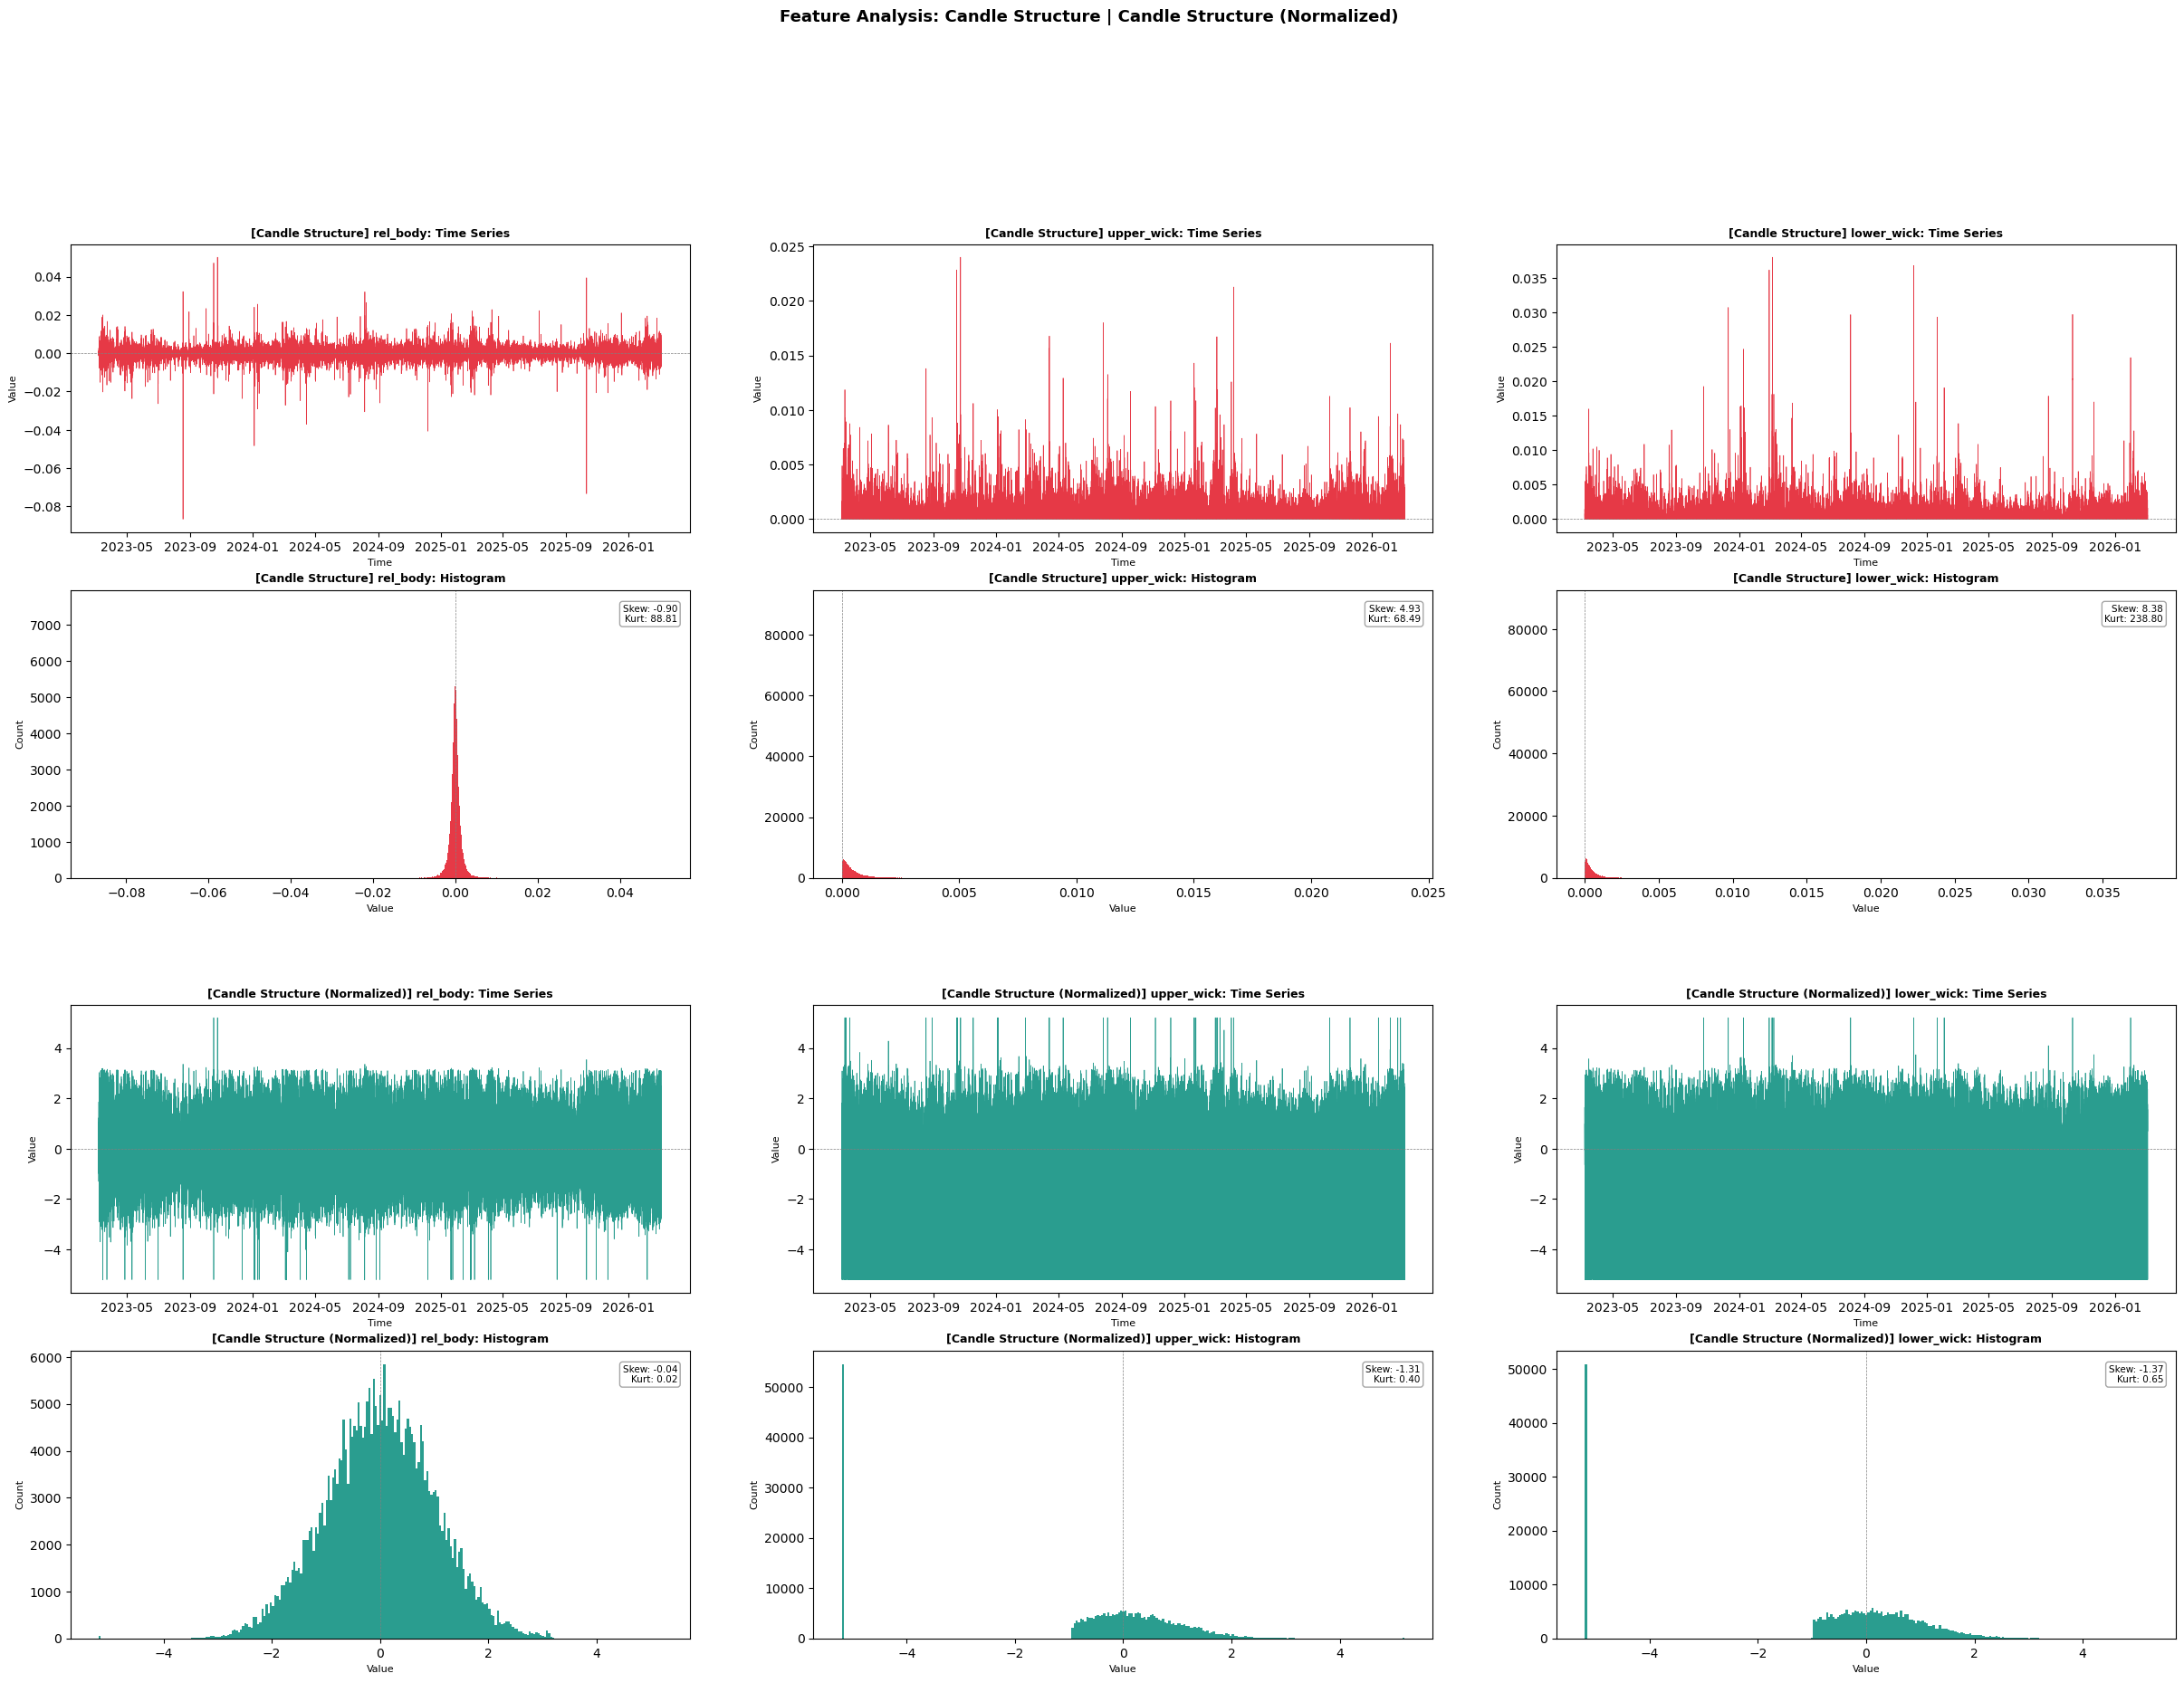

In [4]:
from framework.analysis.features.candles import CandleStructure

cs = CandleStructure()

cs_raw = cs.calculate(df)
cs_raw.dropna(inplace=True)

cs_norm = cs.fit(cs_raw).transform(cs_raw)
cs_norm.dropna(inplace=True)

plot_and_describe([
    (cs_raw, "Candle Structure"),
    (cs_norm, "Candle Structure (Normalized)"),
])

[MACD: macd_line]
count       315311.000000
mean             1.080501
std            119.481632
min          -2165.719543
25%            -35.929297
50%              1.688543
75%             41.974537
max           1713.440432
skew            -0.193771
kurtosis        14.192174
dtype: float64

[MACD: macd_signal]
count       315311.000000
mean             1.080922
std            112.568567
min          -1581.427863
25%            -33.834708
50%              1.641824
75%             39.770765
max           1543.369576
skew            -0.134538
kurtosis        12.791104
dtype: float64

[MACD: macd_hist]
count       3.153110e+05
mean       -3.810843e-08
std         4.901682e-04
min        -9.431217e-03
25%        -2.034277e-04
50%        -2.122937e-06
75%         2.044771e-04
max         6.515587e-03
skew       -2.249818e-01
kurtosis    1.485137e+01
dtype: float64

[MACD (Normalized): macd_hist]
count       315311.000000
mean             0.000900
std              0.999896
min             -

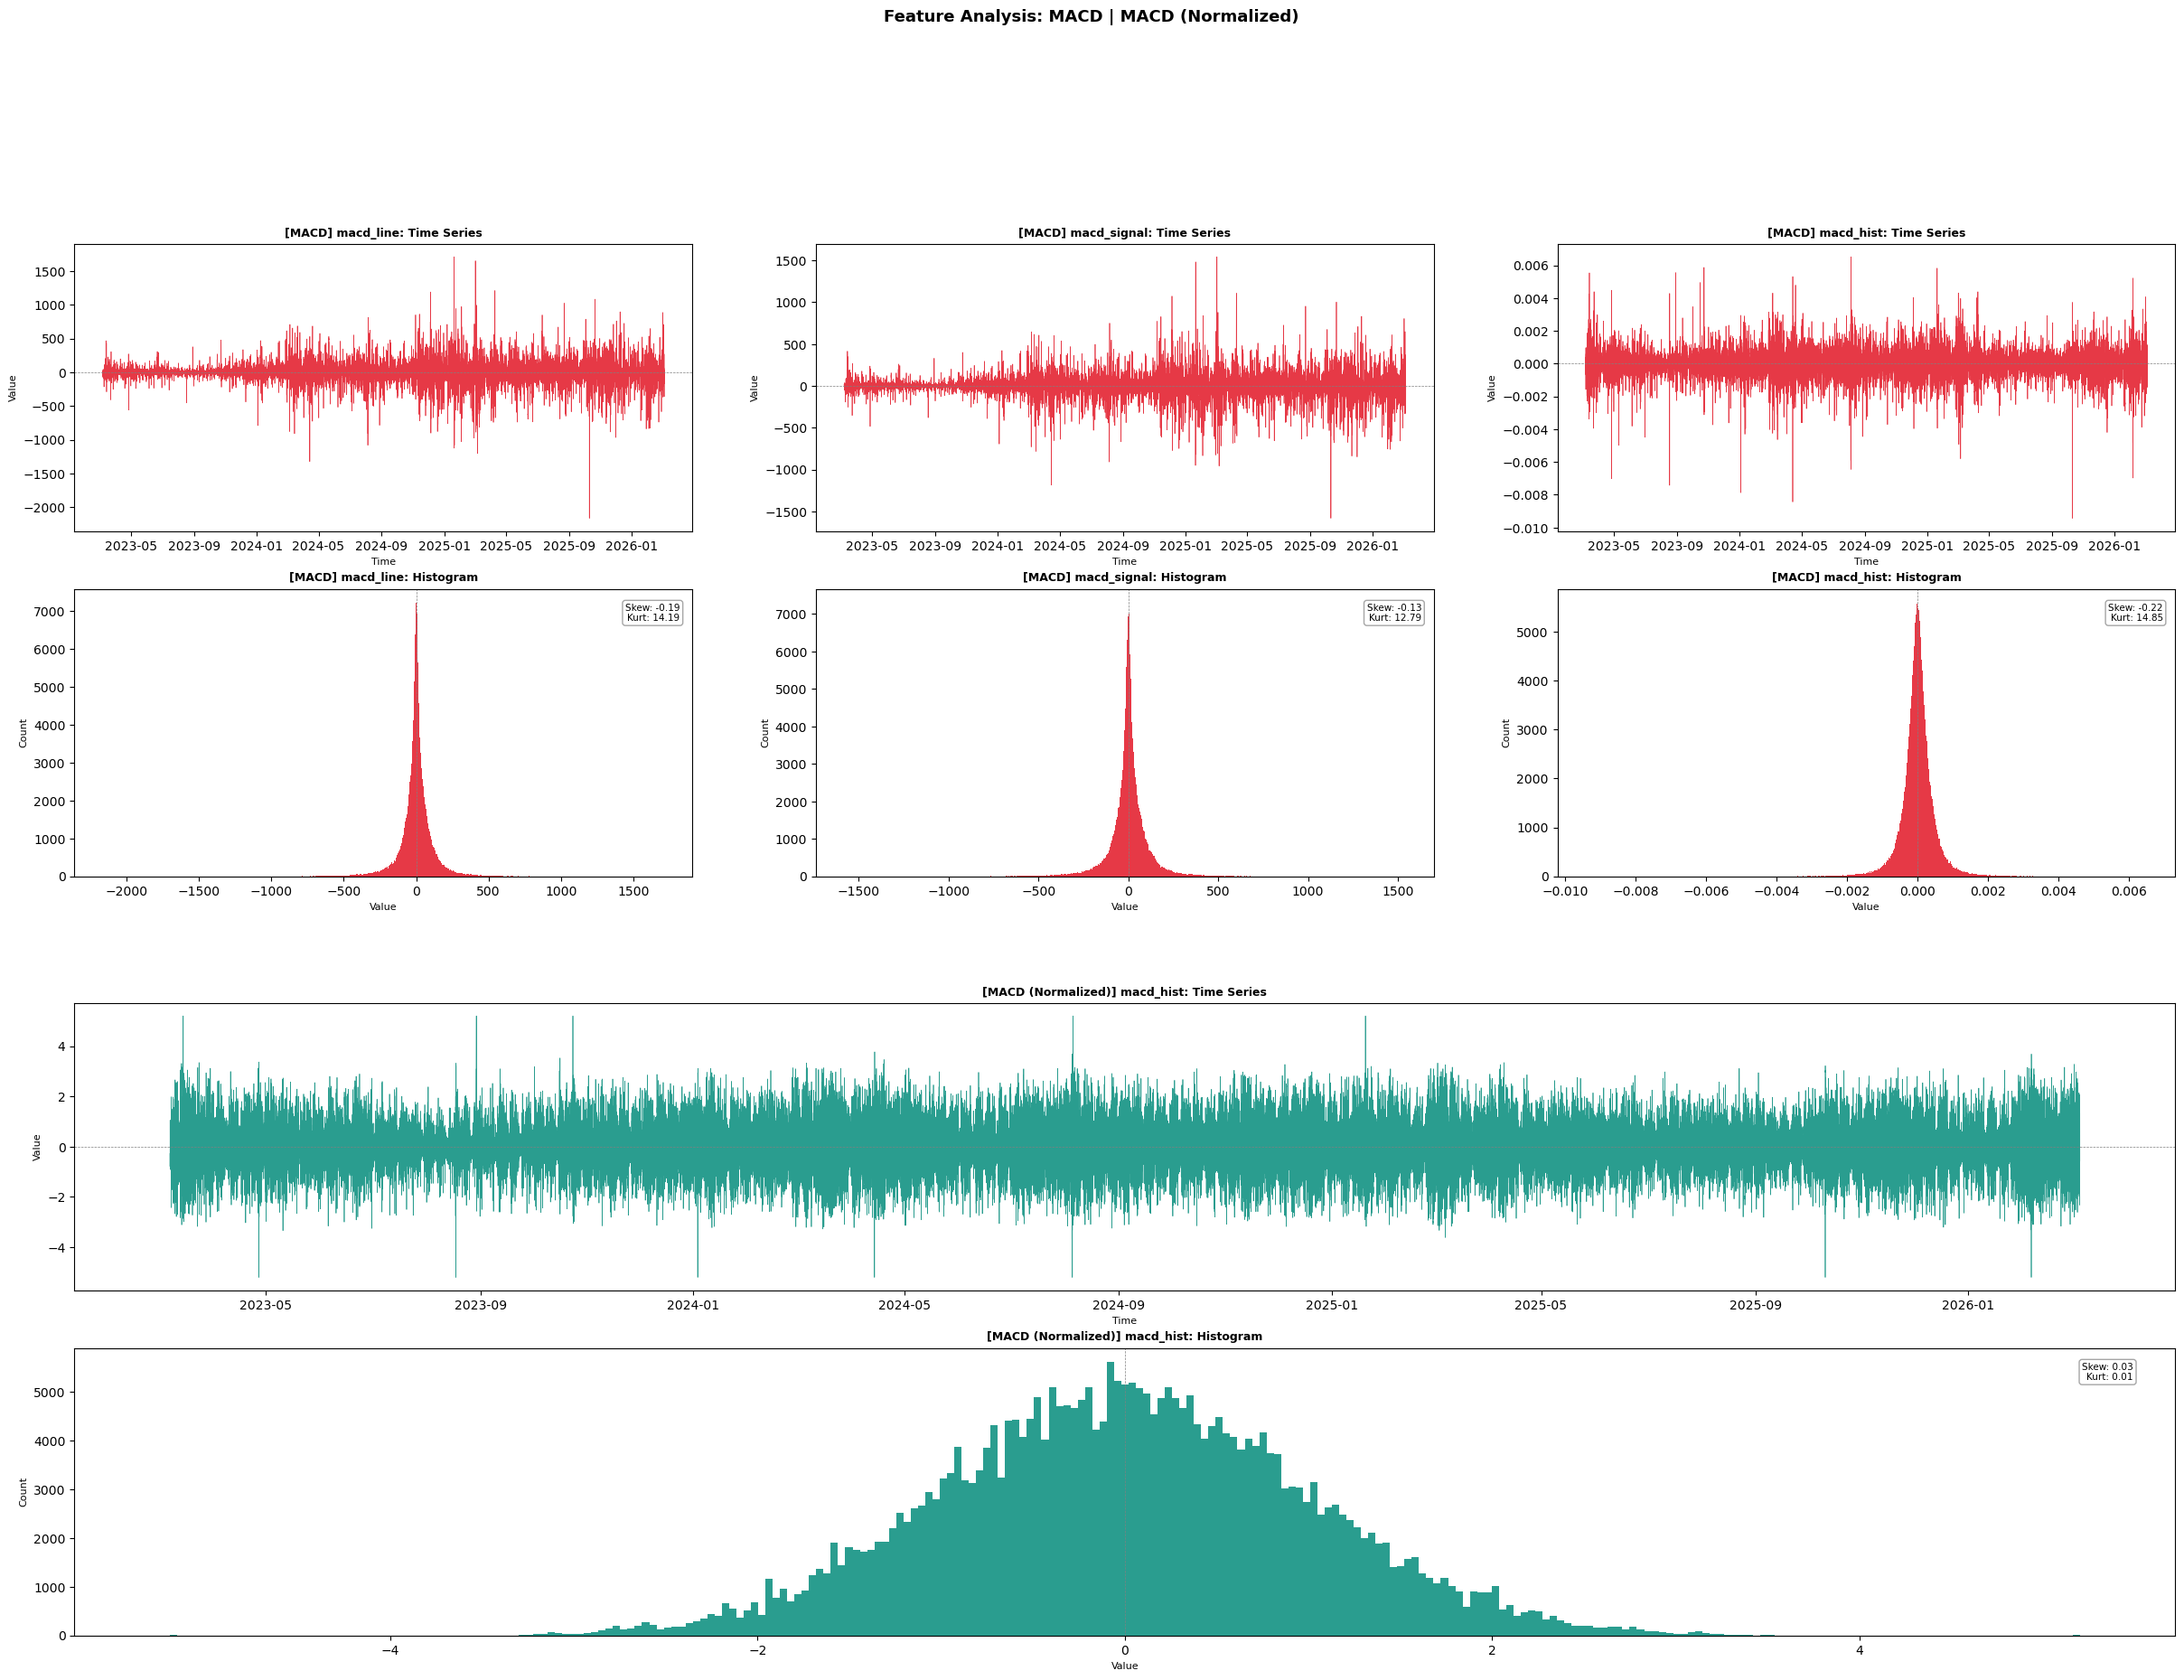

In [5]:
from framework.analysis.features.momentum import MovingAverageConvergenceDivergence

macd = MovingAverageConvergenceDivergence()

macd_raw = macd.calculate(df)
macd_raw.dropna(inplace=True)

macd_norm = macd.fit(macd_raw).transform(macd_raw)
macd_norm.dropna(inplace=True)

plot_and_describe([
    (macd_raw, "MACD"),
    (macd_norm, "MACD (Normalized)"),
])

[RSI: rsi]
count       315330.000000
mean            50.324633
std             10.917474
min              4.414268
25%             43.177972
50%             50.397343
75%             57.456853
max             97.423889
skew            -0.005276
kurtosis         0.287033
dtype: float64

[RSI (Normalized): rsi]
count       315330.000000
mean            -0.012782
std              0.234760
min             -1.000000
25%             -0.166458
50%             -0.011219
75%              0.140583
max              1.000000
skew            -0.005276
kurtosis         0.287033
dtype: float64



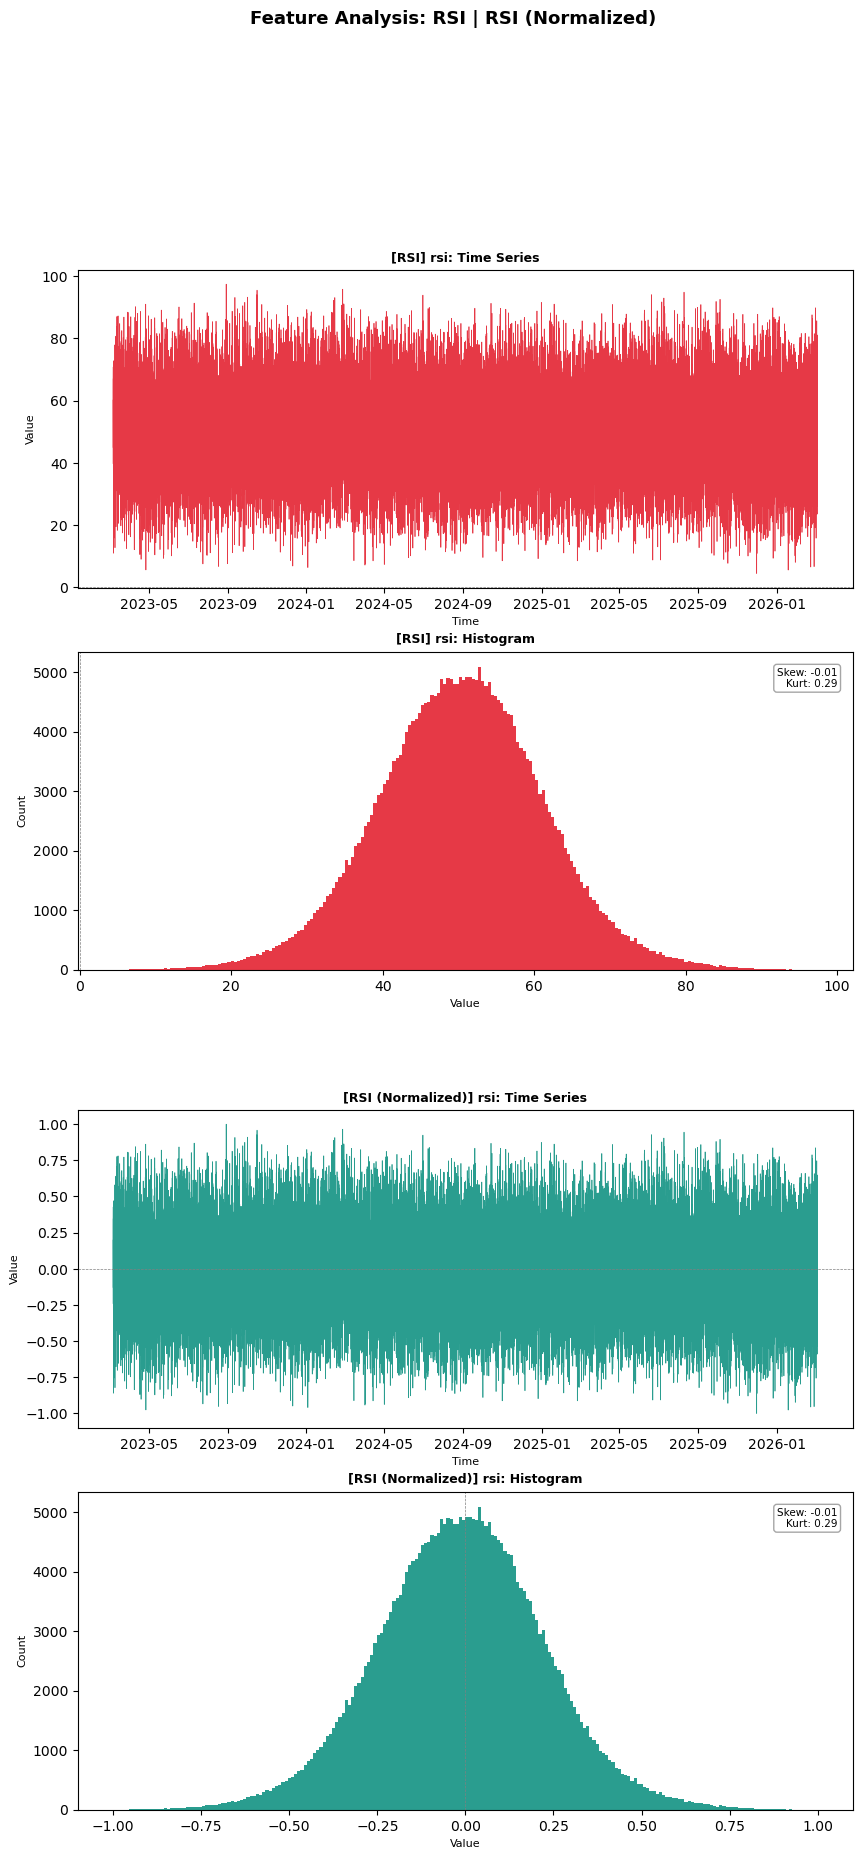

In [6]:
from framework.analysis.features.momentum import RelativeStrengthIndex

rsi = RelativeStrengthIndex()

rsi_raw = rsi.calculate(df)
rsi_raw.dropna(inplace=True)

rsi_norm = rsi.fit(rsi_raw).transform(rsi_raw)
rsi_norm.dropna(inplace=True)

plot_and_describe([
    (rsi_raw, "RSI"),
    (rsi_norm, "RSI (Normalized)"),
])

[TTM Squeeze: sqz]
count       315327.000000
mean             0.000031
std              0.004376
min             -0.071091
25%             -0.001625
50%              0.000050
75%              0.001762
max              0.054681
skew            -0.426358
kurtosis        16.597313
dtype: float64

[TTM Squeeze: sqz_on]
count       315327.000000
mean             0.150698
std              0.357754
min              0.000000
25%              0.000000
50%              0.000000
75%              0.000000
max              1.000000
skew             1.952763
kurtosis         1.813293
dtype: float64

[TTM Squeeze (Normalized): sqz]
count       315327.000000
mean             0.005328
std              1.002751
min             -5.199338
25%             -0.670583
50%              0.000748
75%              0.683109
max              5.199338
skew             0.006069
kurtosis         0.060183
dtype: float64

[TTM Squeeze (Normalized): sqz_on]
count       315327.000000
mean             0.150698
std         

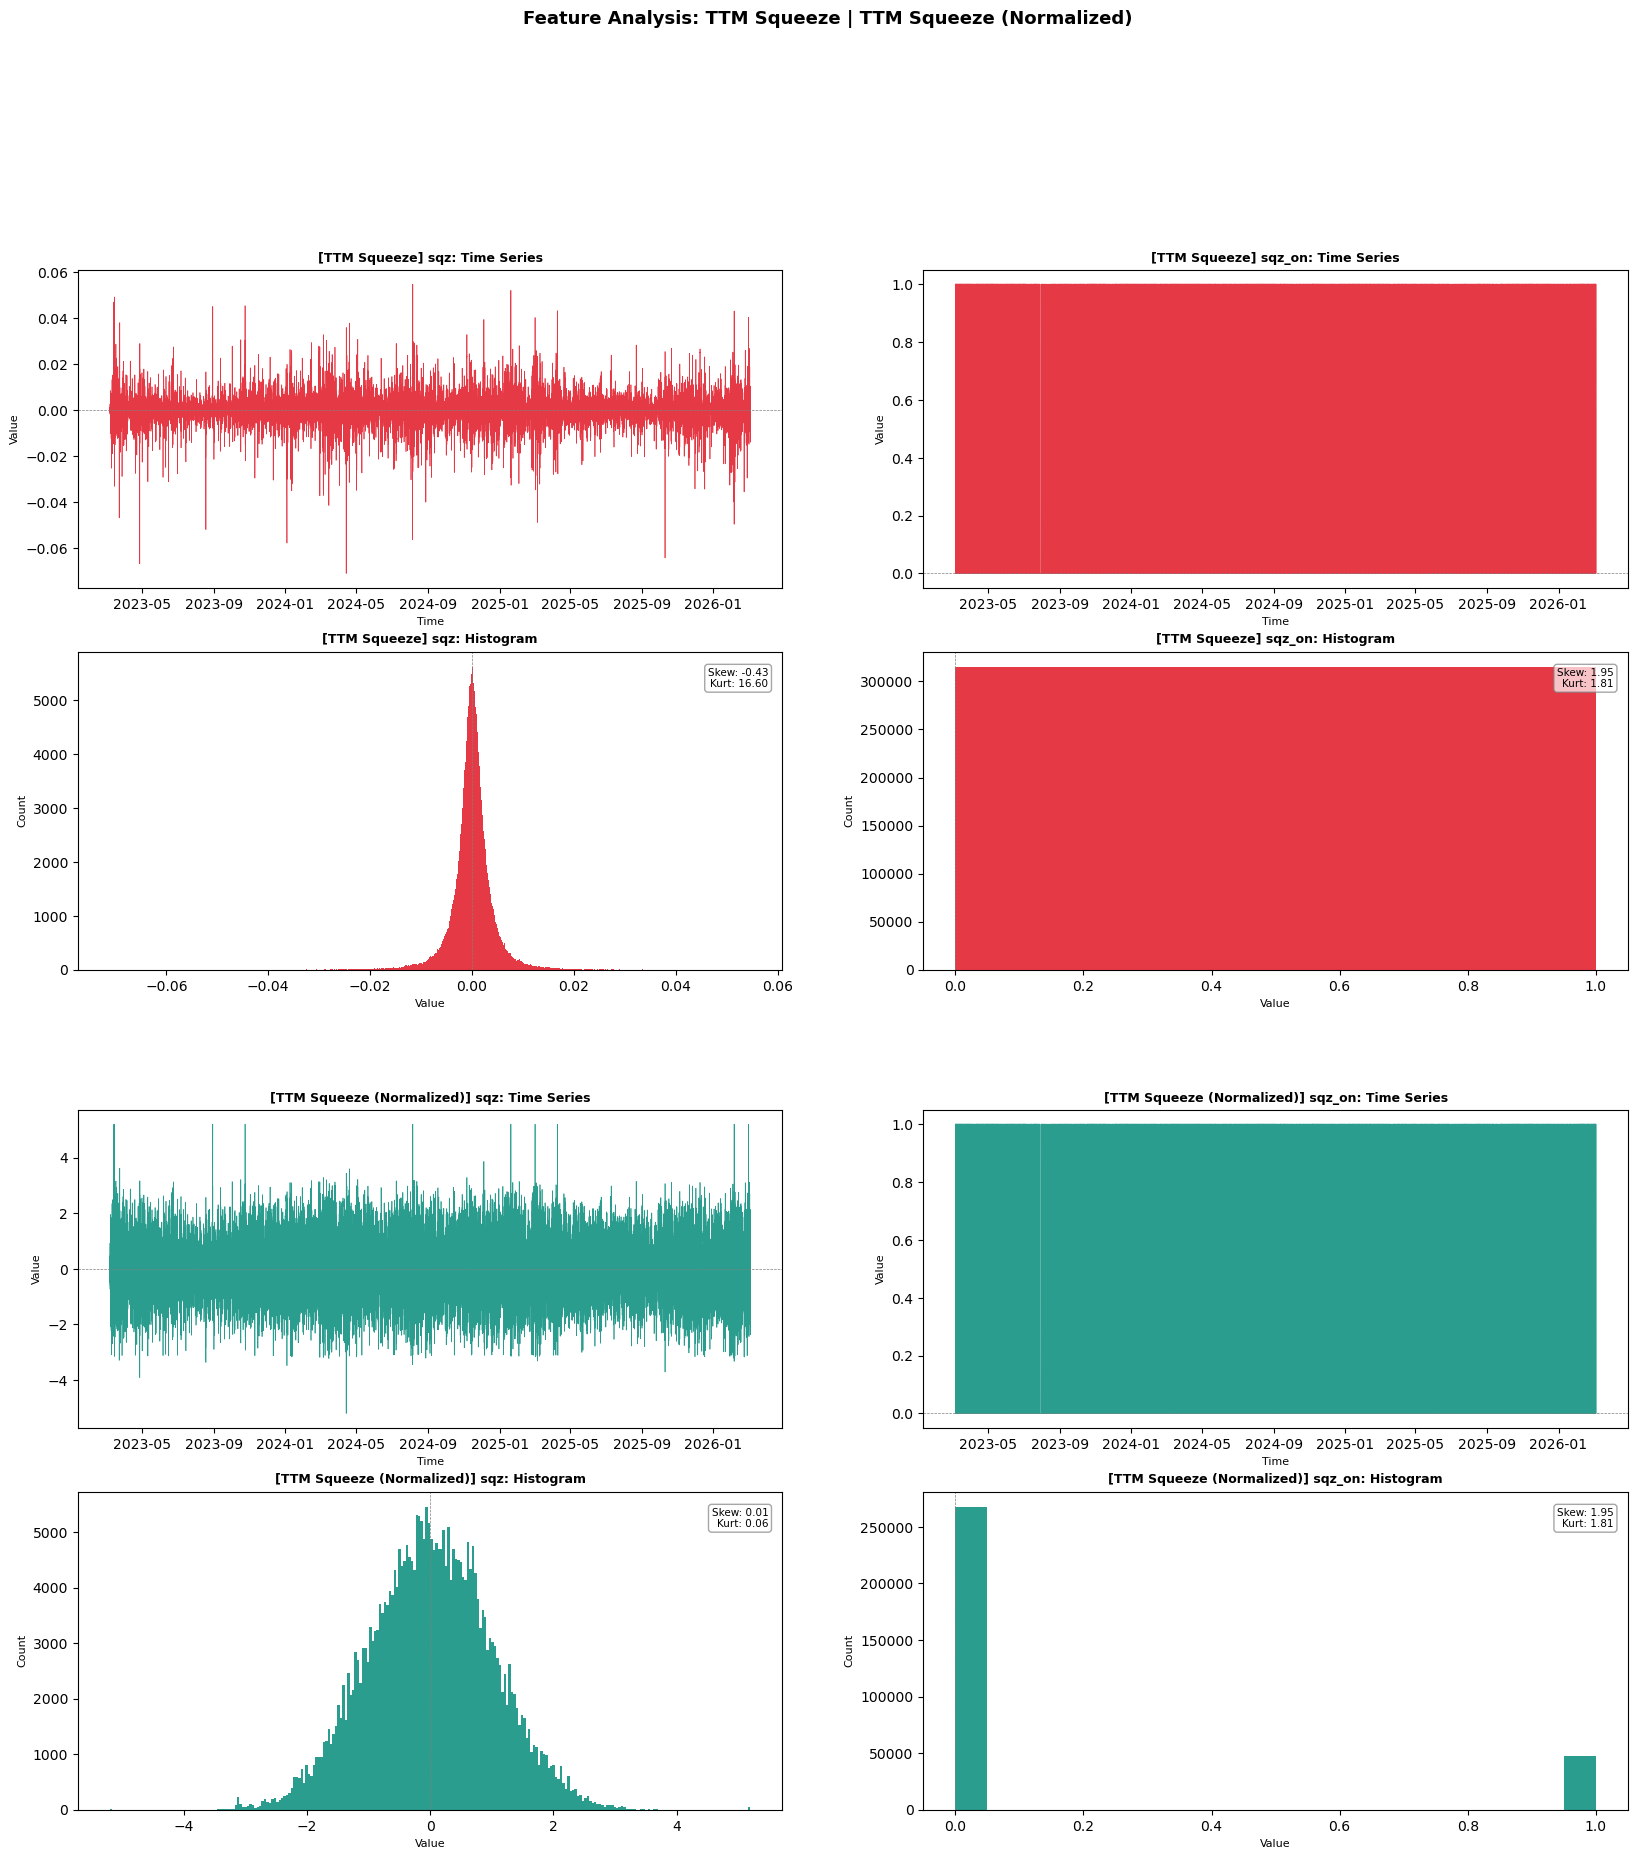

In [7]:
from framework.analysis.features.momentum import TTMSqueeze

sqz = TTMSqueeze()

sqz_raw = sqz.calculate(df)
sqz_raw.dropna(inplace=True)

sqz_norm = sqz.fit(sqz_raw).transform(sqz_raw)
sqz_norm.dropna(inplace=True)

plot_and_describe([
    (sqz_raw, "TTM Squeeze"),
    (sqz_norm, "TTM Squeeze (Normalized)"),
])

[Super Trend: st_line]
count       315337.000000
mean         68862.683951
std          30122.269130
min          19607.797176
25%          39900.931441
50%          67218.205470
75%          95634.431297
max         126001.449943
skew             0.007536
kurtosis        -1.294680
dtype: float64

[Super Trend: st_dist]
count       315337.000000
mean            -0.000082
std              0.005240
min             -0.109223
25%             -0.003018
50%              0.000105
75%              0.002976
max              0.067338
skew            -0.349732
kurtosis         6.265312
dtype: float64

[Super Trend (Normalized): st_dist]
count       315337.000000
mean            -0.009213
std              1.002031
min             -5.199338
25%             -0.685752
50%             -0.004211
75%              0.659304
max              5.199338
skew             0.011037
kurtosis         0.105307
dtype: float64



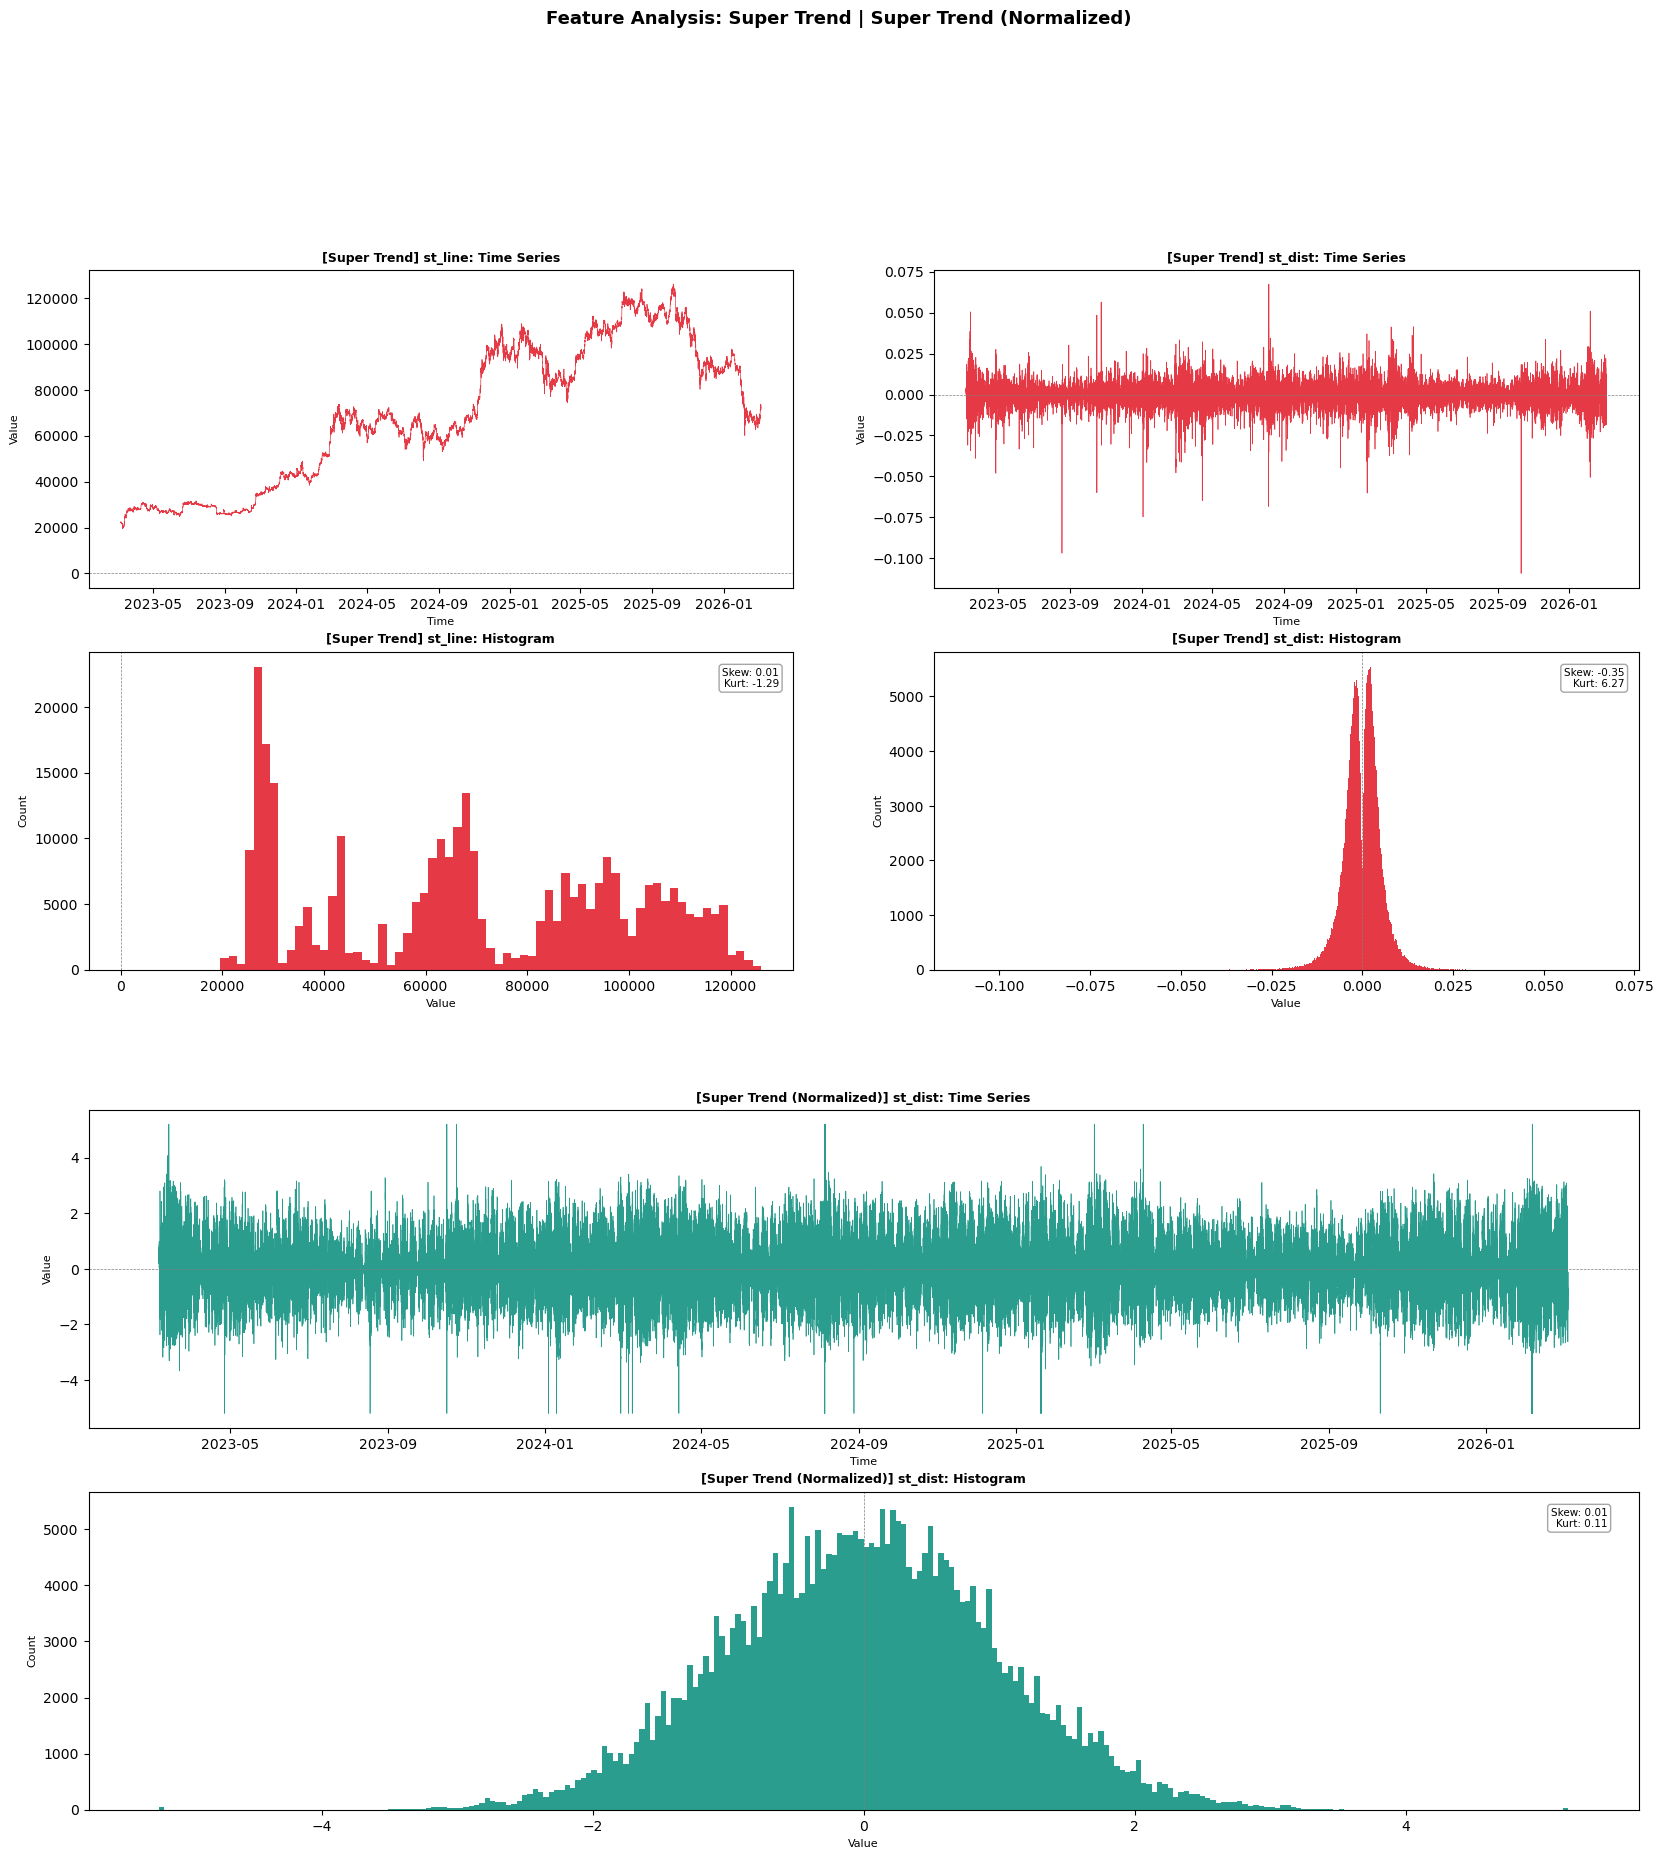

In [8]:
from framework.analysis.features.overlap import SuperTrend

strend = SuperTrend()

strend_raw = strend.calculate(df)
strend_raw.dropna(inplace=True)

strend_norm = strend.fit(strend_raw).transform(strend_raw)
strend_norm.dropna(inplace=True)

plot_and_describe([
    (strend_raw, "Super Trend"),
    (strend_norm, "Super Trend (Normalized)"),
])

[Exponential Moving Average: ema_spread]
count       315317.000000
mean             0.000023
std              0.001556
min             -0.019054
25%             -0.000552
50%              0.000033
75%              0.000627
max              0.018652
skew            -0.161868
kurtosis        11.798967
dtype: float64

[Exponential Moving Average (Normalized): ema_spread]
count       315317.000000
mean             0.005542
std              1.000147
min             -5.199338
25%             -0.672033
50%              0.017218
75%              0.680194
max              5.199338
skew             0.008161
kurtosis         0.119113
dtype: float64



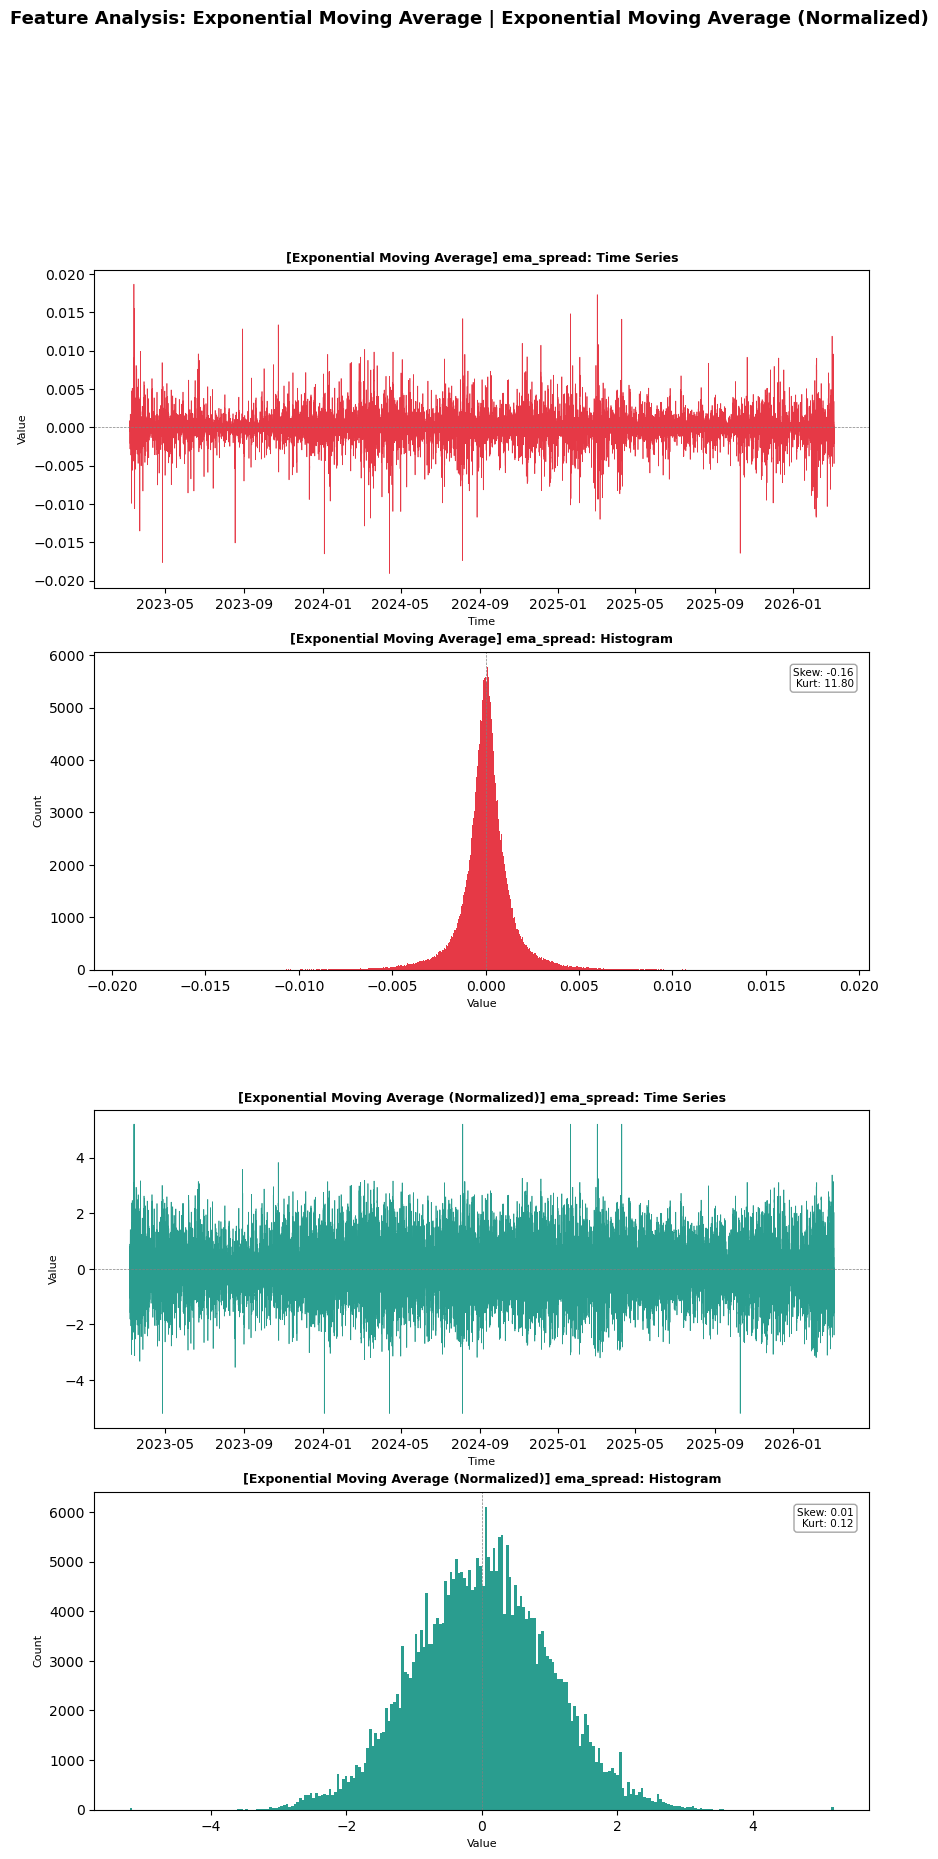

In [9]:
from framework.analysis.features.overlap import ExponentialMovingAverage

ema = ExponentialMovingAverage()

ema_raw = ema.calculate(df)
ema_raw.dropna(inplace=True)

ema_norm = ema.fit(ema_raw).transform(ema_raw)
ema_norm.dropna(inplace=True)

plot_and_describe([
    (ema_raw, "Exponential Moving Average"),
    (ema_norm, "Exponential Moving Average (Normalized)"),
])

[Draw Down: dd_line]
count       315344.000000
mean         11031.471785
std          12606.259070
min              0.000000
25%           2690.137500
50%           6166.220000
75%          13607.715000
max          65929.440000
skew             1.996094
kurtosis         3.901957
dtype: float64

[Draw Down: dd_pct]
count       315344.000000
mean             0.121570
std              0.098270
min              0.000000
25%              0.044109
50%              0.102934
75%              0.168935
max              0.523203
skew             1.361596
kurtosis         2.075569
dtype: float64

[Draw Down (Normalized): dd_pct]
count       315344.000000
mean            -0.019744
std              1.033912
min             -5.199338
25%             -0.697167
50%             -0.010688
75%              0.668813
max              5.199338
skew            -0.177367
kurtosis         1.239231
dtype: float64



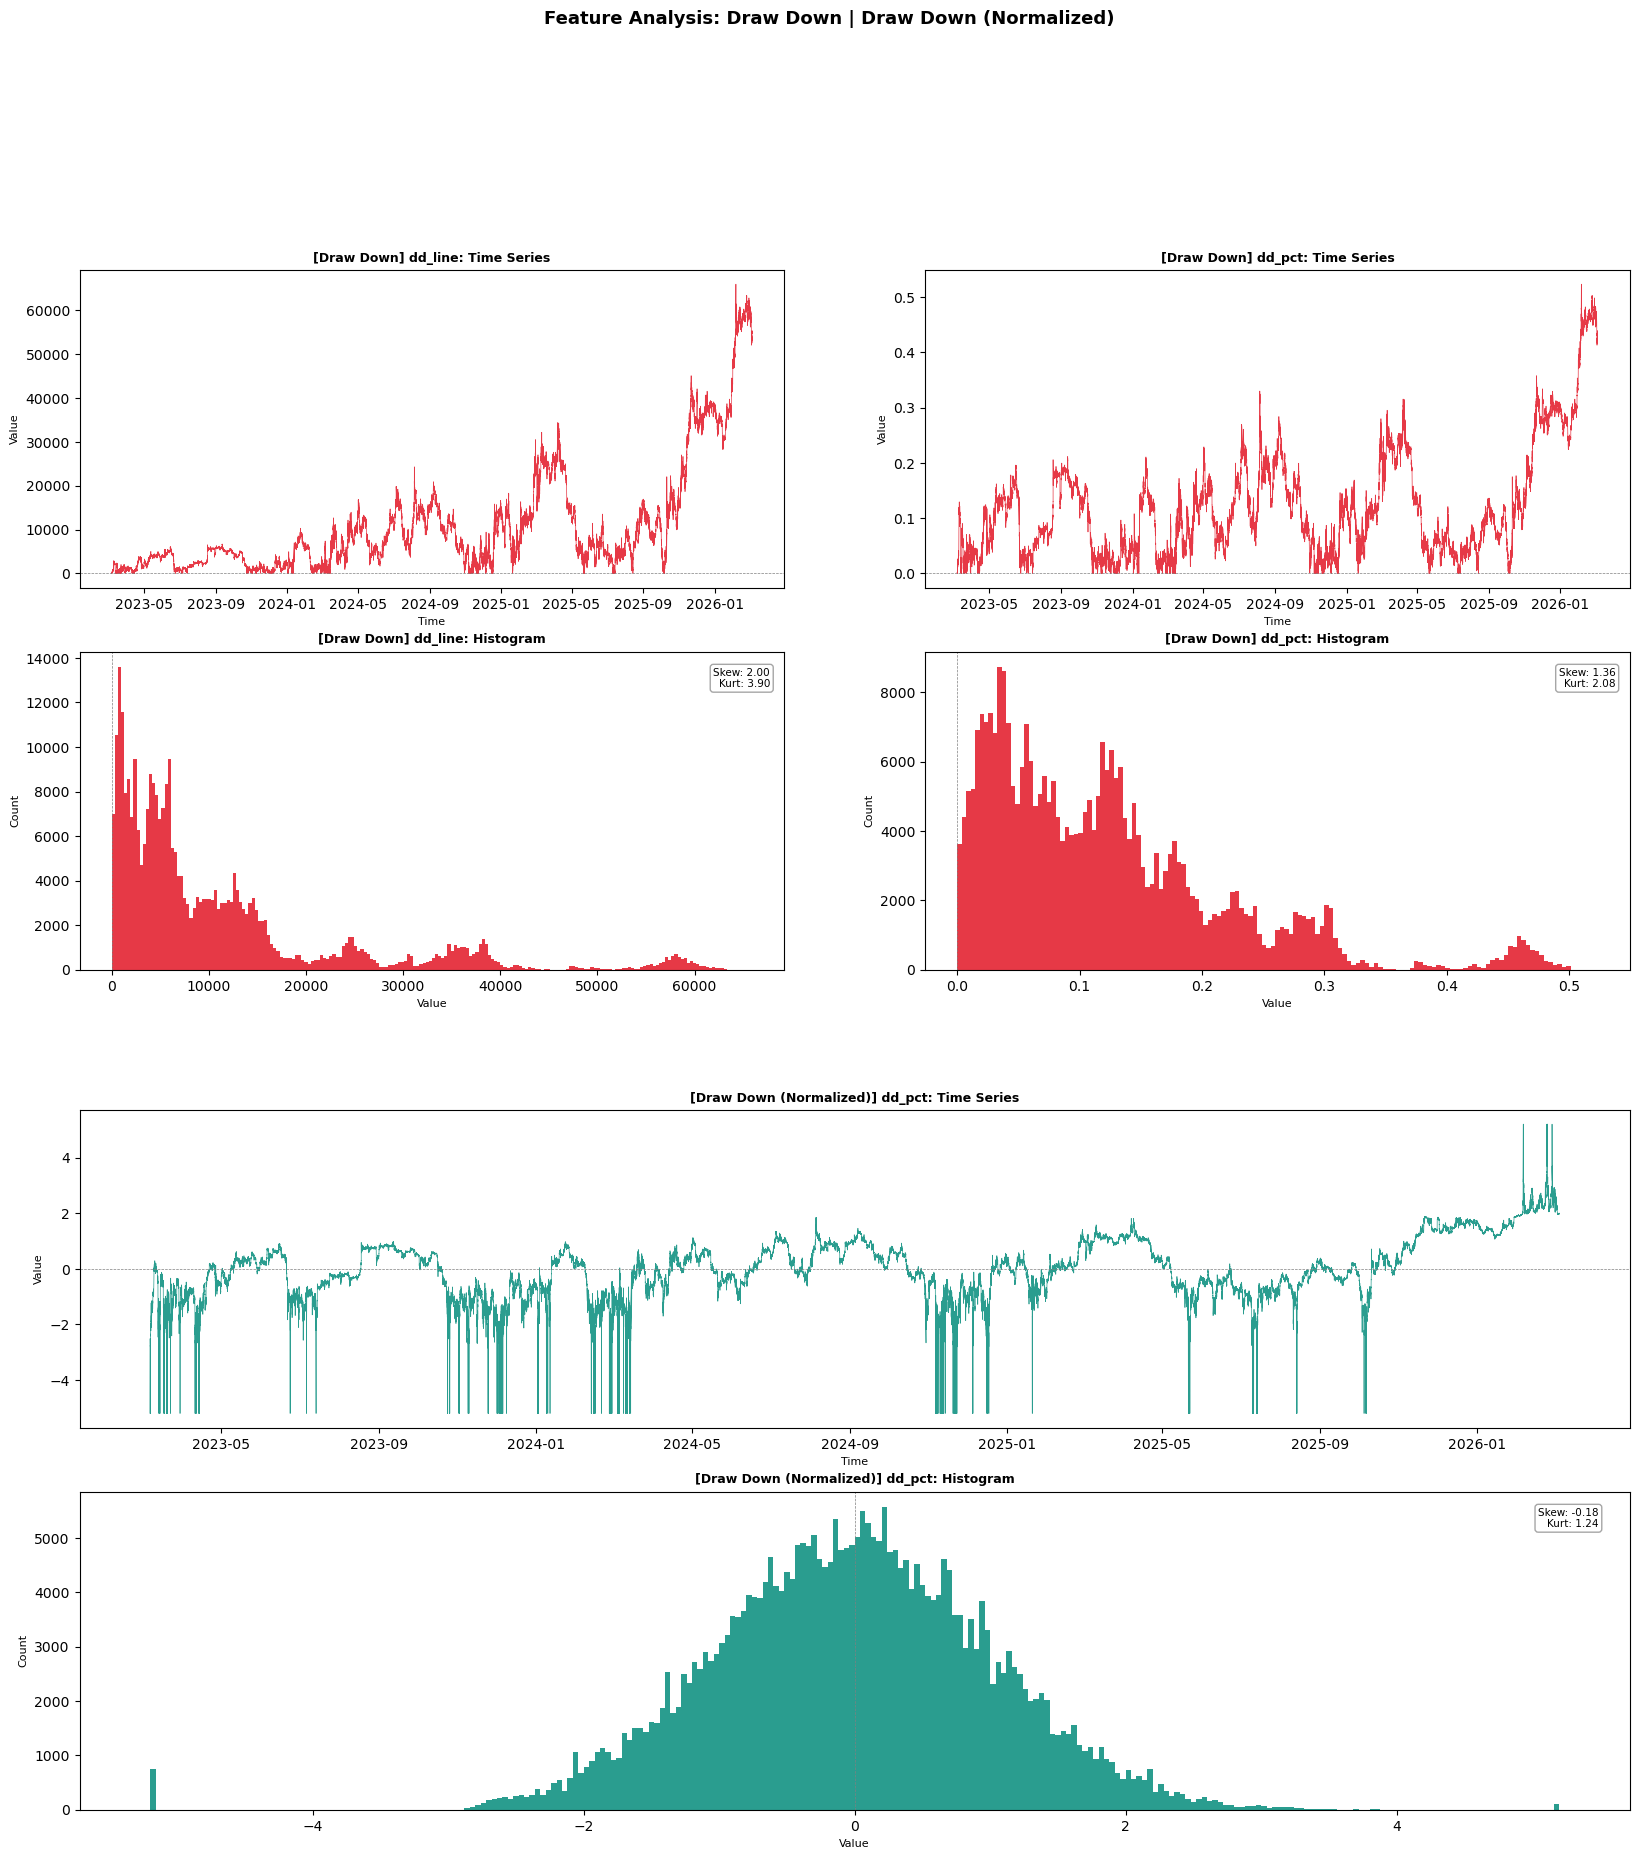

In [10]:
from framework.analysis.features.performance import DrawDown

dd = DrawDown()

dd_raw = dd.calculate(df)
dd_raw.dropna(inplace=True)

dd_norm = dd.fit(dd_raw).transform(dd_raw)
dd_norm.dropna(inplace=True)

plot_and_describe([
    (dd_raw, "Draw Down"),
    (dd_norm, "Draw Down (Normalized)"),
])

[Log Return: log_return]
count       315324.000000
mean             0.000073
std              0.006459
min             -0.113280
25%             -0.002443
50%              0.000088
75%              0.002648
max              0.089621
skew            -0.155180
kurtosis        13.963647
dtype: float64

[Log Return (Normalized): log_return]
count       315324.000000
mean            -0.000159
std              1.000867
min             -5.199338
25%             -0.670626
50%             -0.003831
75%              0.662869
max              5.199338
skew            -0.041655
kurtosis         0.143592
dtype: float64



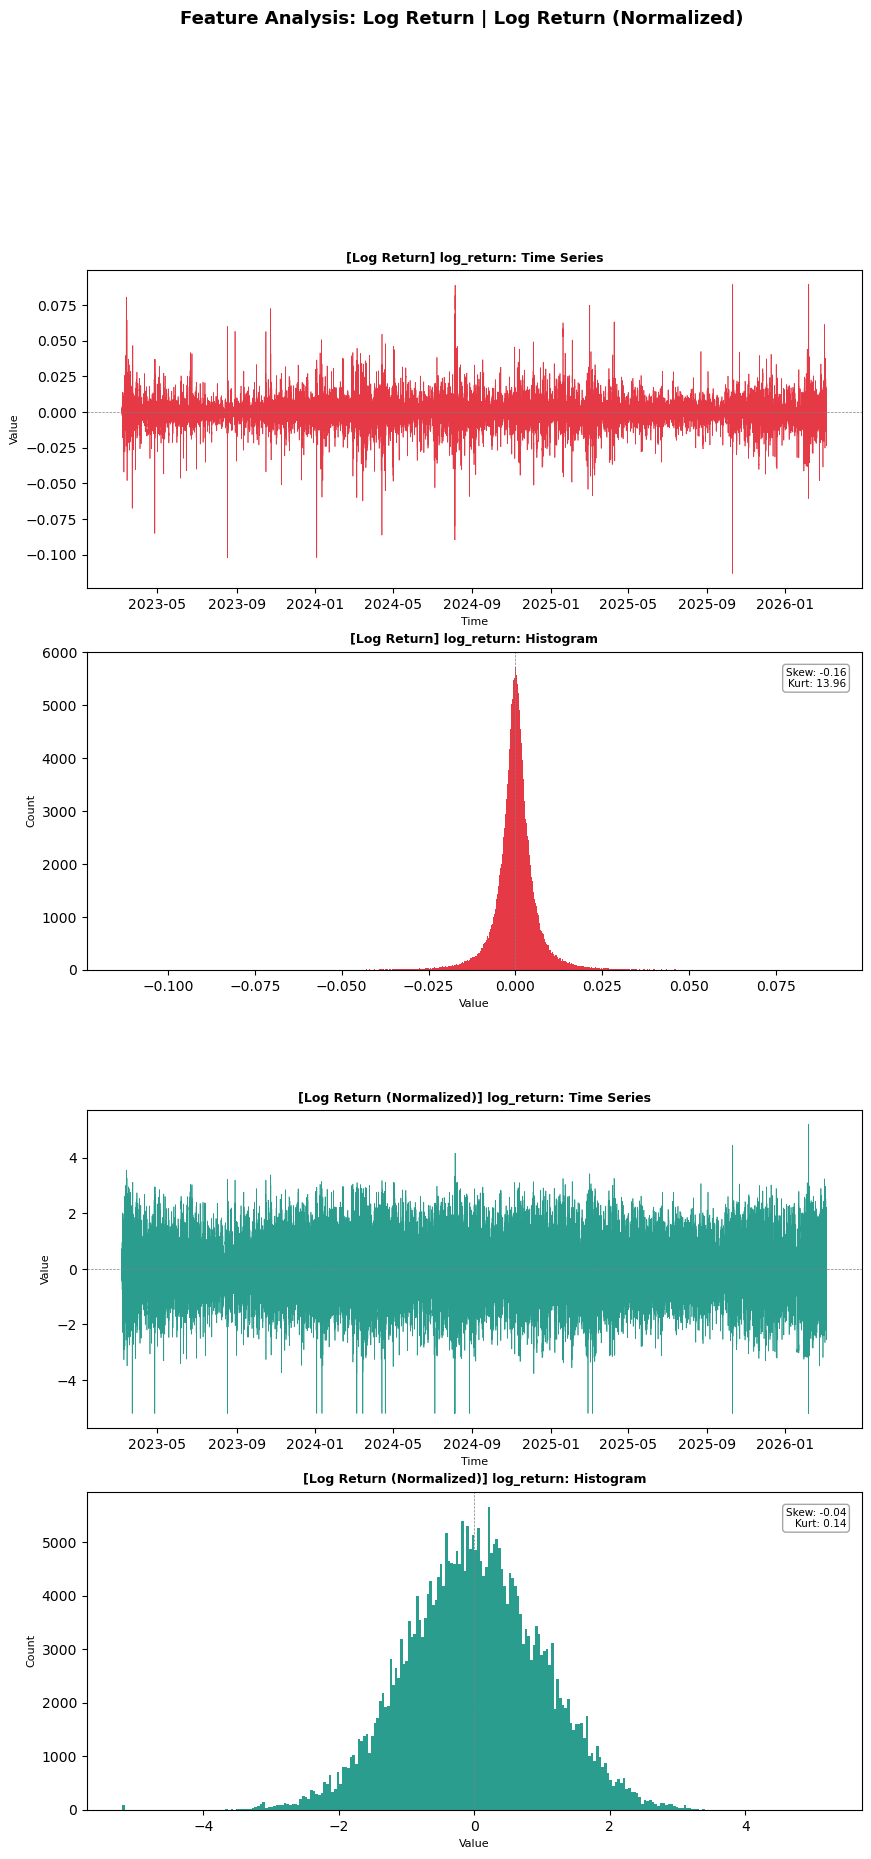

In [11]:
from framework.analysis.features.performance import LogReturn

logret = LogReturn()

logret_raw = logret.calculate(df)
logret_raw.dropna(inplace=True)

logret_norm = logret.fit(logret_raw).transform(logret_raw)
logret_norm.dropna(inplace=True)

plot_and_describe([
    (logret_raw, "Log Return"),
    (logret_norm, "Log Return (Normalized)"),
])

[Average Directional Index: adx]
count       315317.000000
mean            25.072818
std             10.559887
min              5.498393
25%             17.229588
50%             22.766161
75%             30.634200
max             78.507508
skew             1.093870
kurtosis         1.226399
dtype: float64

[Average Directional Index: adx_osc]
count       315317.000000
mean            -0.249954
std             15.366470
min            -80.348715
25%            -10.432523
50%             -0.277396
75%              9.823286
max             79.737461
skew             0.033318
kurtosis         0.306619
dtype: float64

[Average Directional Index (Normalized): adx]
count       315317.000000
mean            -0.016820
std              1.009834
min             -5.199338
25%             -0.701254
50%             -0.020607
75%              0.654076
max              5.199338
skew             0.021787
kurtosis         0.043012
dtype: float64



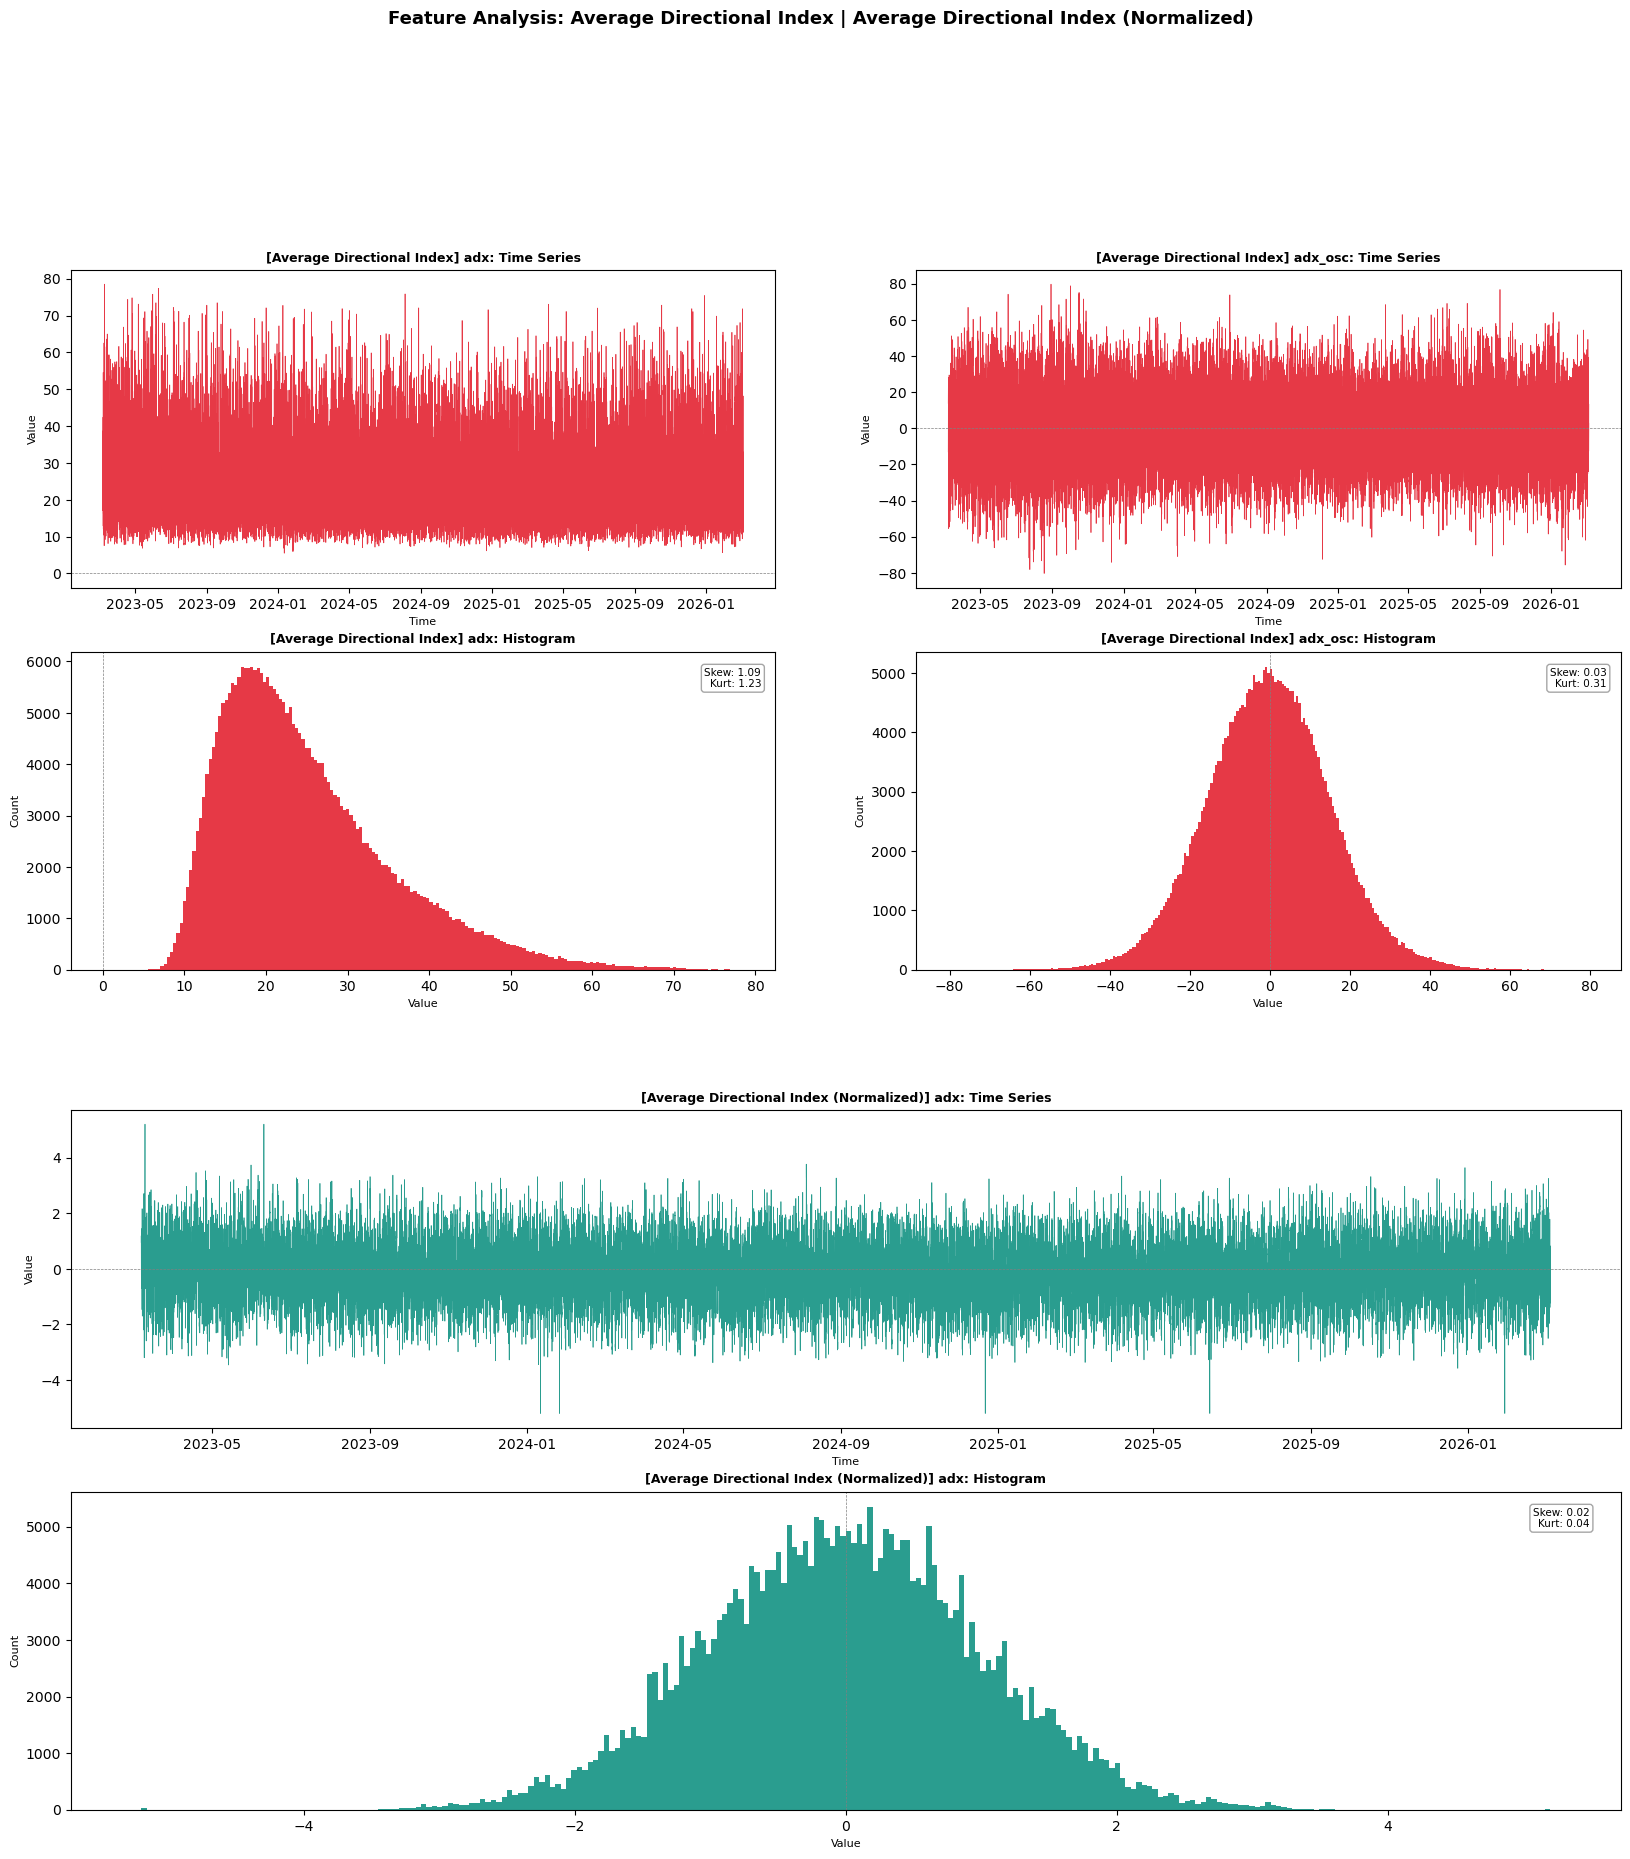

In [12]:
from framework.analysis.features.trend import AverageDirectionalIndex

adx = AverageDirectionalIndex()

adx_raw = adx.calculate(df)
adx_raw.dropna(inplace=True)

adx_norm = adx.fit(adx_raw).transform(adx_raw)
adx_norm.dropna(inplace=True)

plot_and_describe([
    (adx_raw, "Average Directional Index"),
    (adx_norm, "Average Directional Index (Normalized)"),
])

[Parabolic Stop and Reverse: psar_line]
count       315343.000000
mean         68847.031470
std          30118.485814
min          19549.090000
25%          39883.966164
50%          67209.772760
75%          95584.940287
max         126199.630000
skew             0.007723
kurtosis        -1.294792
dtype: float64

[Parabolic Stop and Reverse: psar_dist]
count       315343.000000
mean             0.000145
std              0.005100
min             -0.118417
25%             -0.002683
50%              0.000291
75%              0.002907
max              0.092701
skew             0.096099
kurtosis        11.645748
dtype: float64

[Parabolic Stop and Reverse (Normalized): psar_dist]
count       315343.000000
mean             0.009683
std              1.004016
min             -5.199338
25%             -0.671423
50%              0.006256
75%              0.680121
max              5.199338
skew             0.010220
kurtosis        -0.065689
dtype: float64



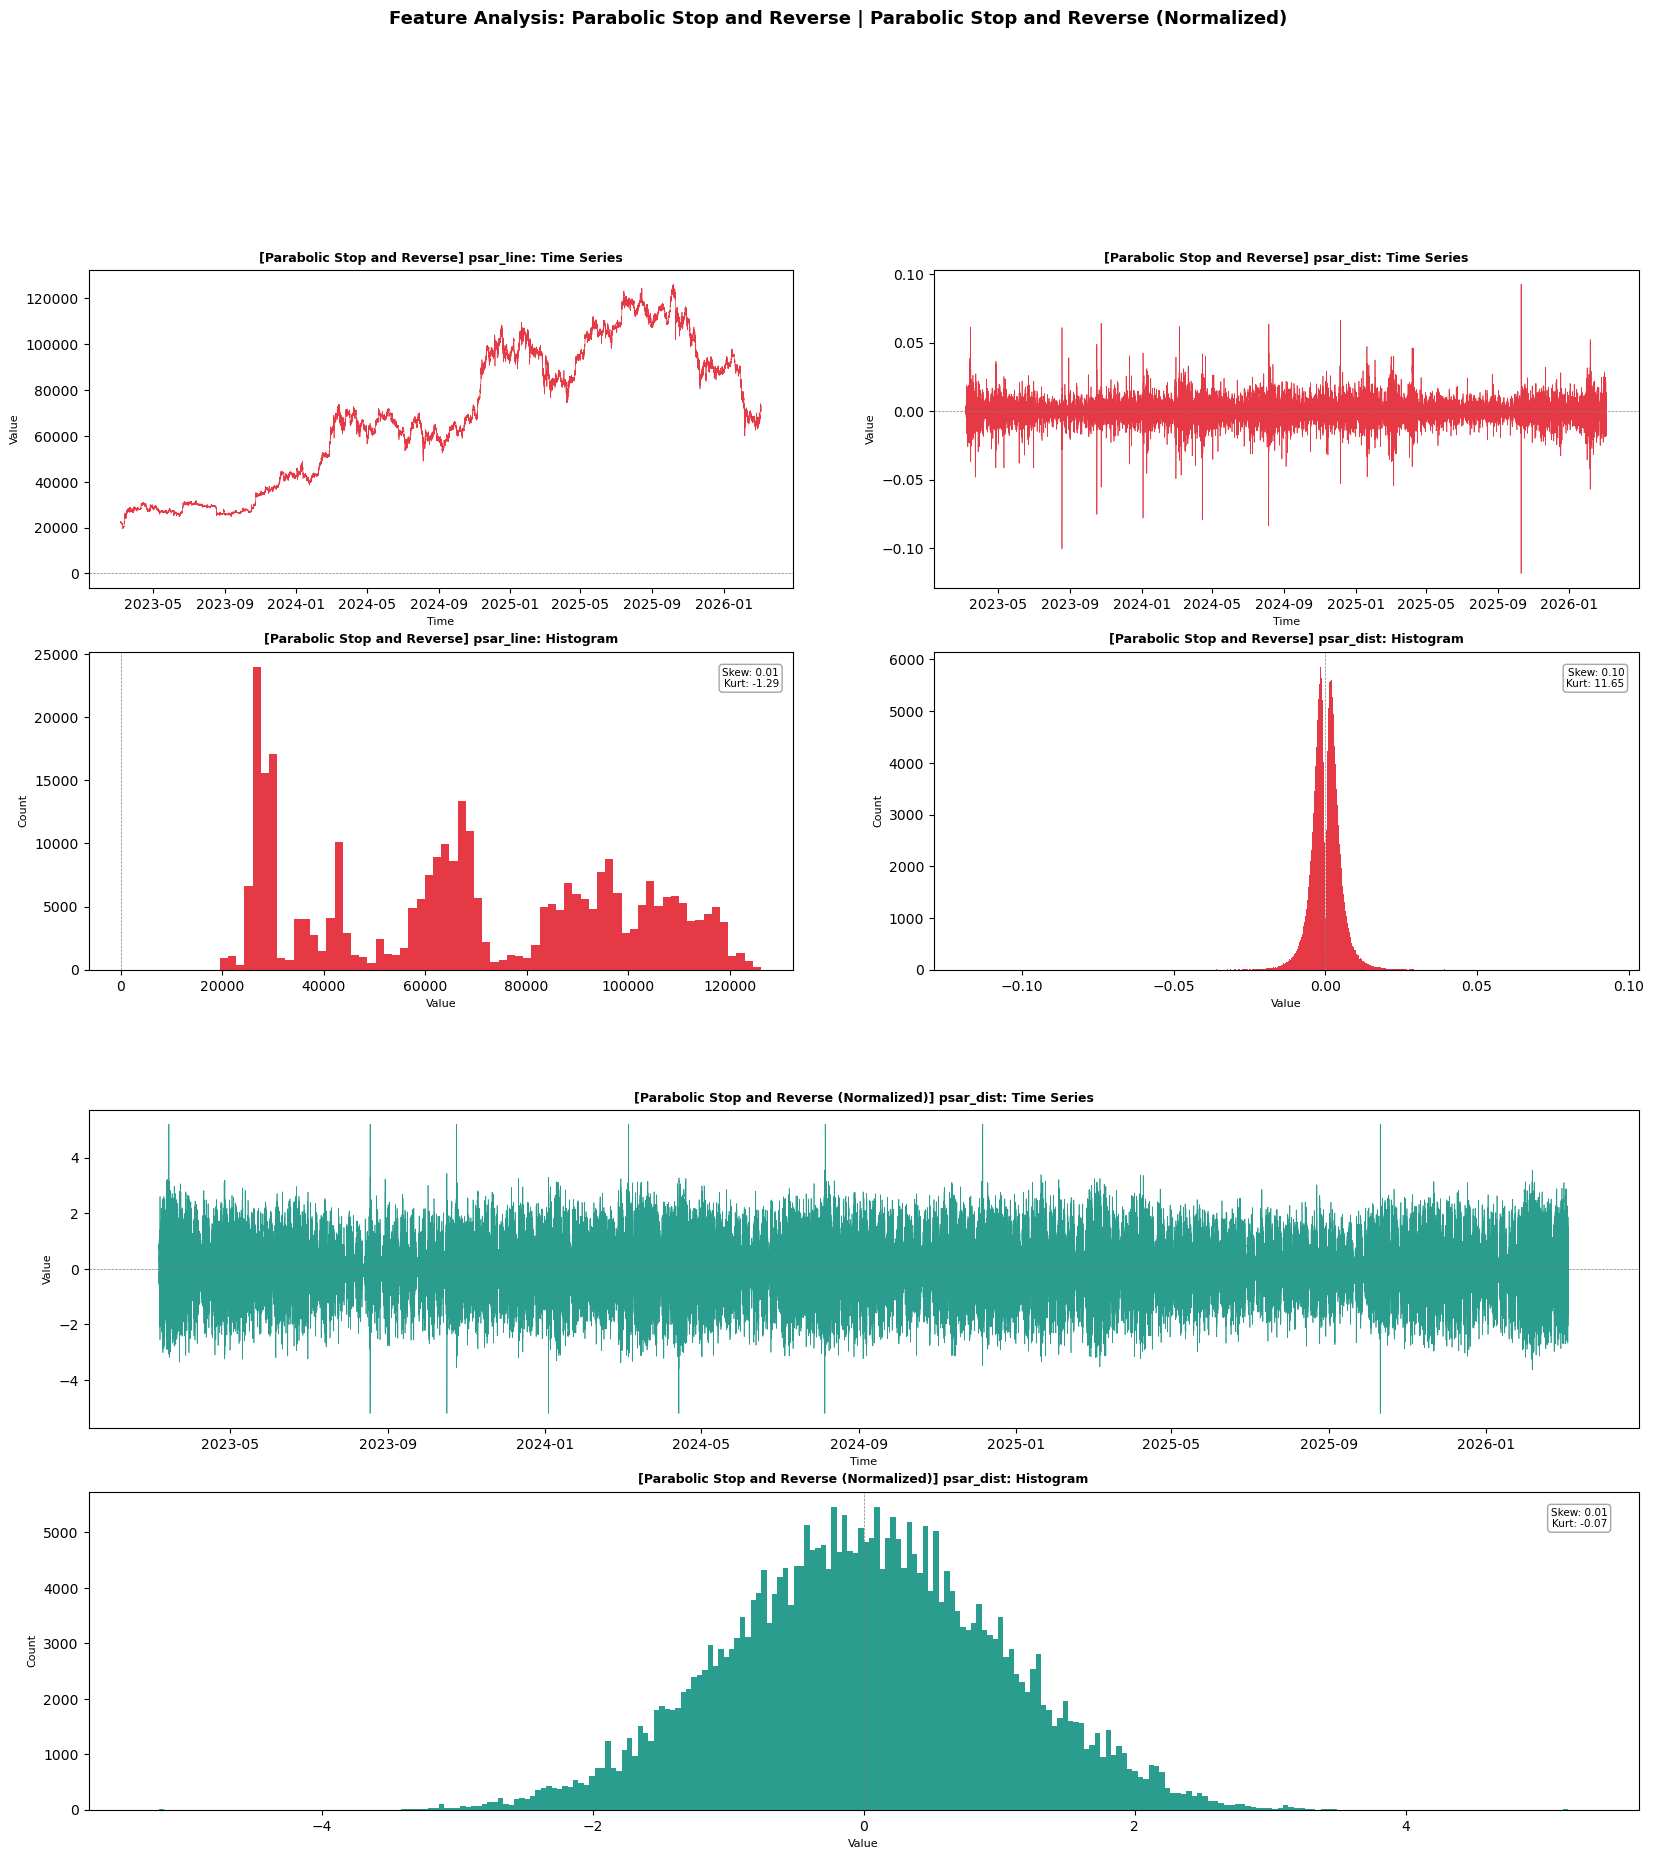

In [13]:
from framework.analysis.features.trend import ParabolicStopAndReverse

psar = ParabolicStopAndReverse()

psar_raw = psar.calculate(df)
psar_raw.dropna(inplace=True)

psar_norm = psar.fit(psar_raw).transform(psar_raw)
psar_norm.dropna(inplace=True)

plot_and_describe([
    (psar_raw, "Parabolic Stop and Reverse"),
    (psar_norm, "Parabolic Stop and Reverse (Normalized)"),
])

[Normalized Average True Range: natr]
count       315330.000000
mean             0.170226
std              0.115516
min              0.004337
25%              0.094307
50%              0.142818
75%              0.214585
max              1.950207
skew             2.396733
kurtosis        12.107017
dtype: float64

[Normalized Average True Range (Normalized): natr]
count       315330.000000
mean            -0.018119
std              0.998709
min             -5.199338
25%             -0.692837
50%             -0.022102
75%              0.650947
max              5.199338
skew            -0.031843
kurtosis         0.182375
dtype: float64



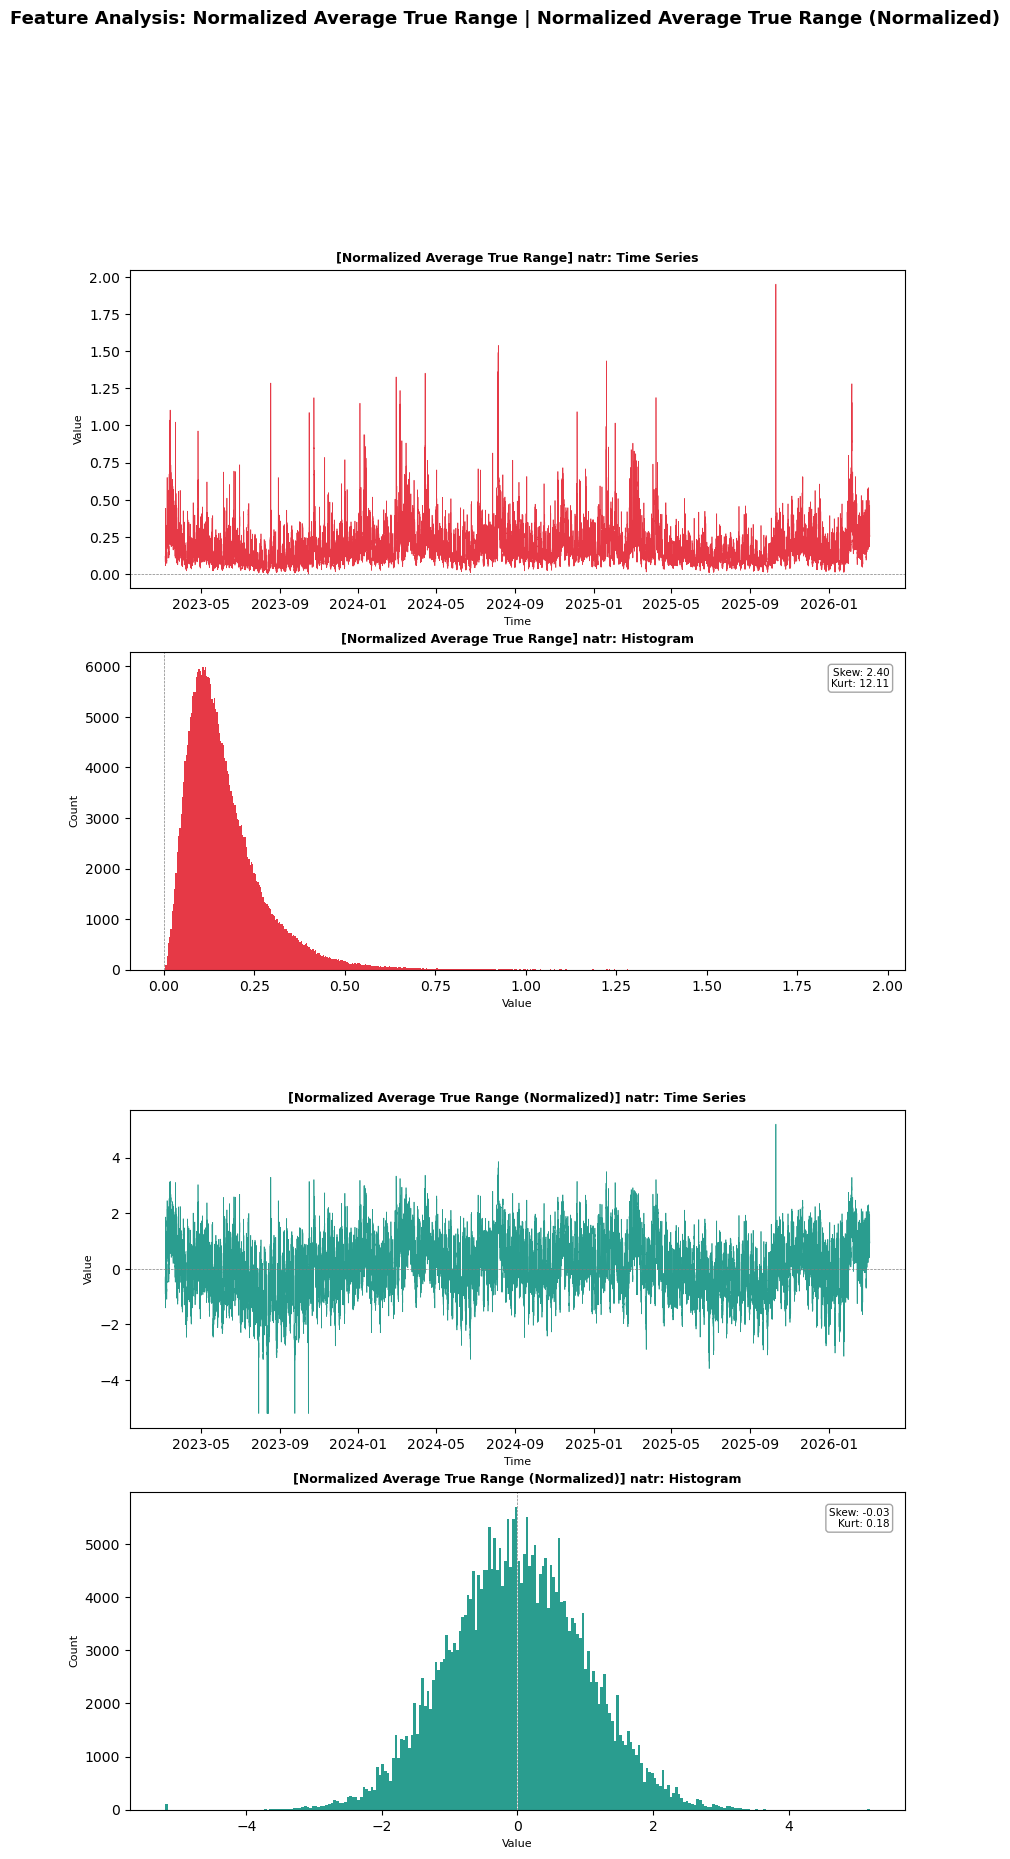

In [14]:
from framework.analysis.features.volatility import NormalizedAverageTrueRange

natr = NormalizedAverageTrueRange()

natr_raw = natr.calculate(df)
natr_raw.dropna(inplace=True)

natr_norm = natr.fit(natr_raw).transform(natr_raw)
natr_norm.dropna(inplace=True)

plot_and_describe([
    (natr_raw, "Normalized Average True Range"),
    (natr_norm, "Normalized Average True Range (Normalized)"),
])

[Bollinger Bands: bb_lower]
count       315325.000000
mean         68586.739498
std          30014.249776
min          19527.597939
25%          39738.787286
50%          66909.627918
75%          95250.064329
max         125169.784461
skew             0.011257
kurtosis        -1.292972
dtype: float64

[Bollinger Bands: bb_mid]
count       315325.000000
mean         68858.354537
std          30119.912812
min          19687.185000
25%          39917.445000
50%          67212.685000
75%          95610.651000
max         125573.133500
skew             0.007382
kurtosis        -1.294955
dtype: float64

[Bollinger Bands: bb_upper]
count       315325.000000
mean         69129.969576
std          30227.772212
min          19794.811343
25%          40066.990182
50%          67524.886686
75%          95977.242963
max         126034.149216
skew             0.003769
kurtosis        -1.296681
dtype: float64

[Bollinger Bands: bb_width]
count       315325.000000
mean             0.782988
std       

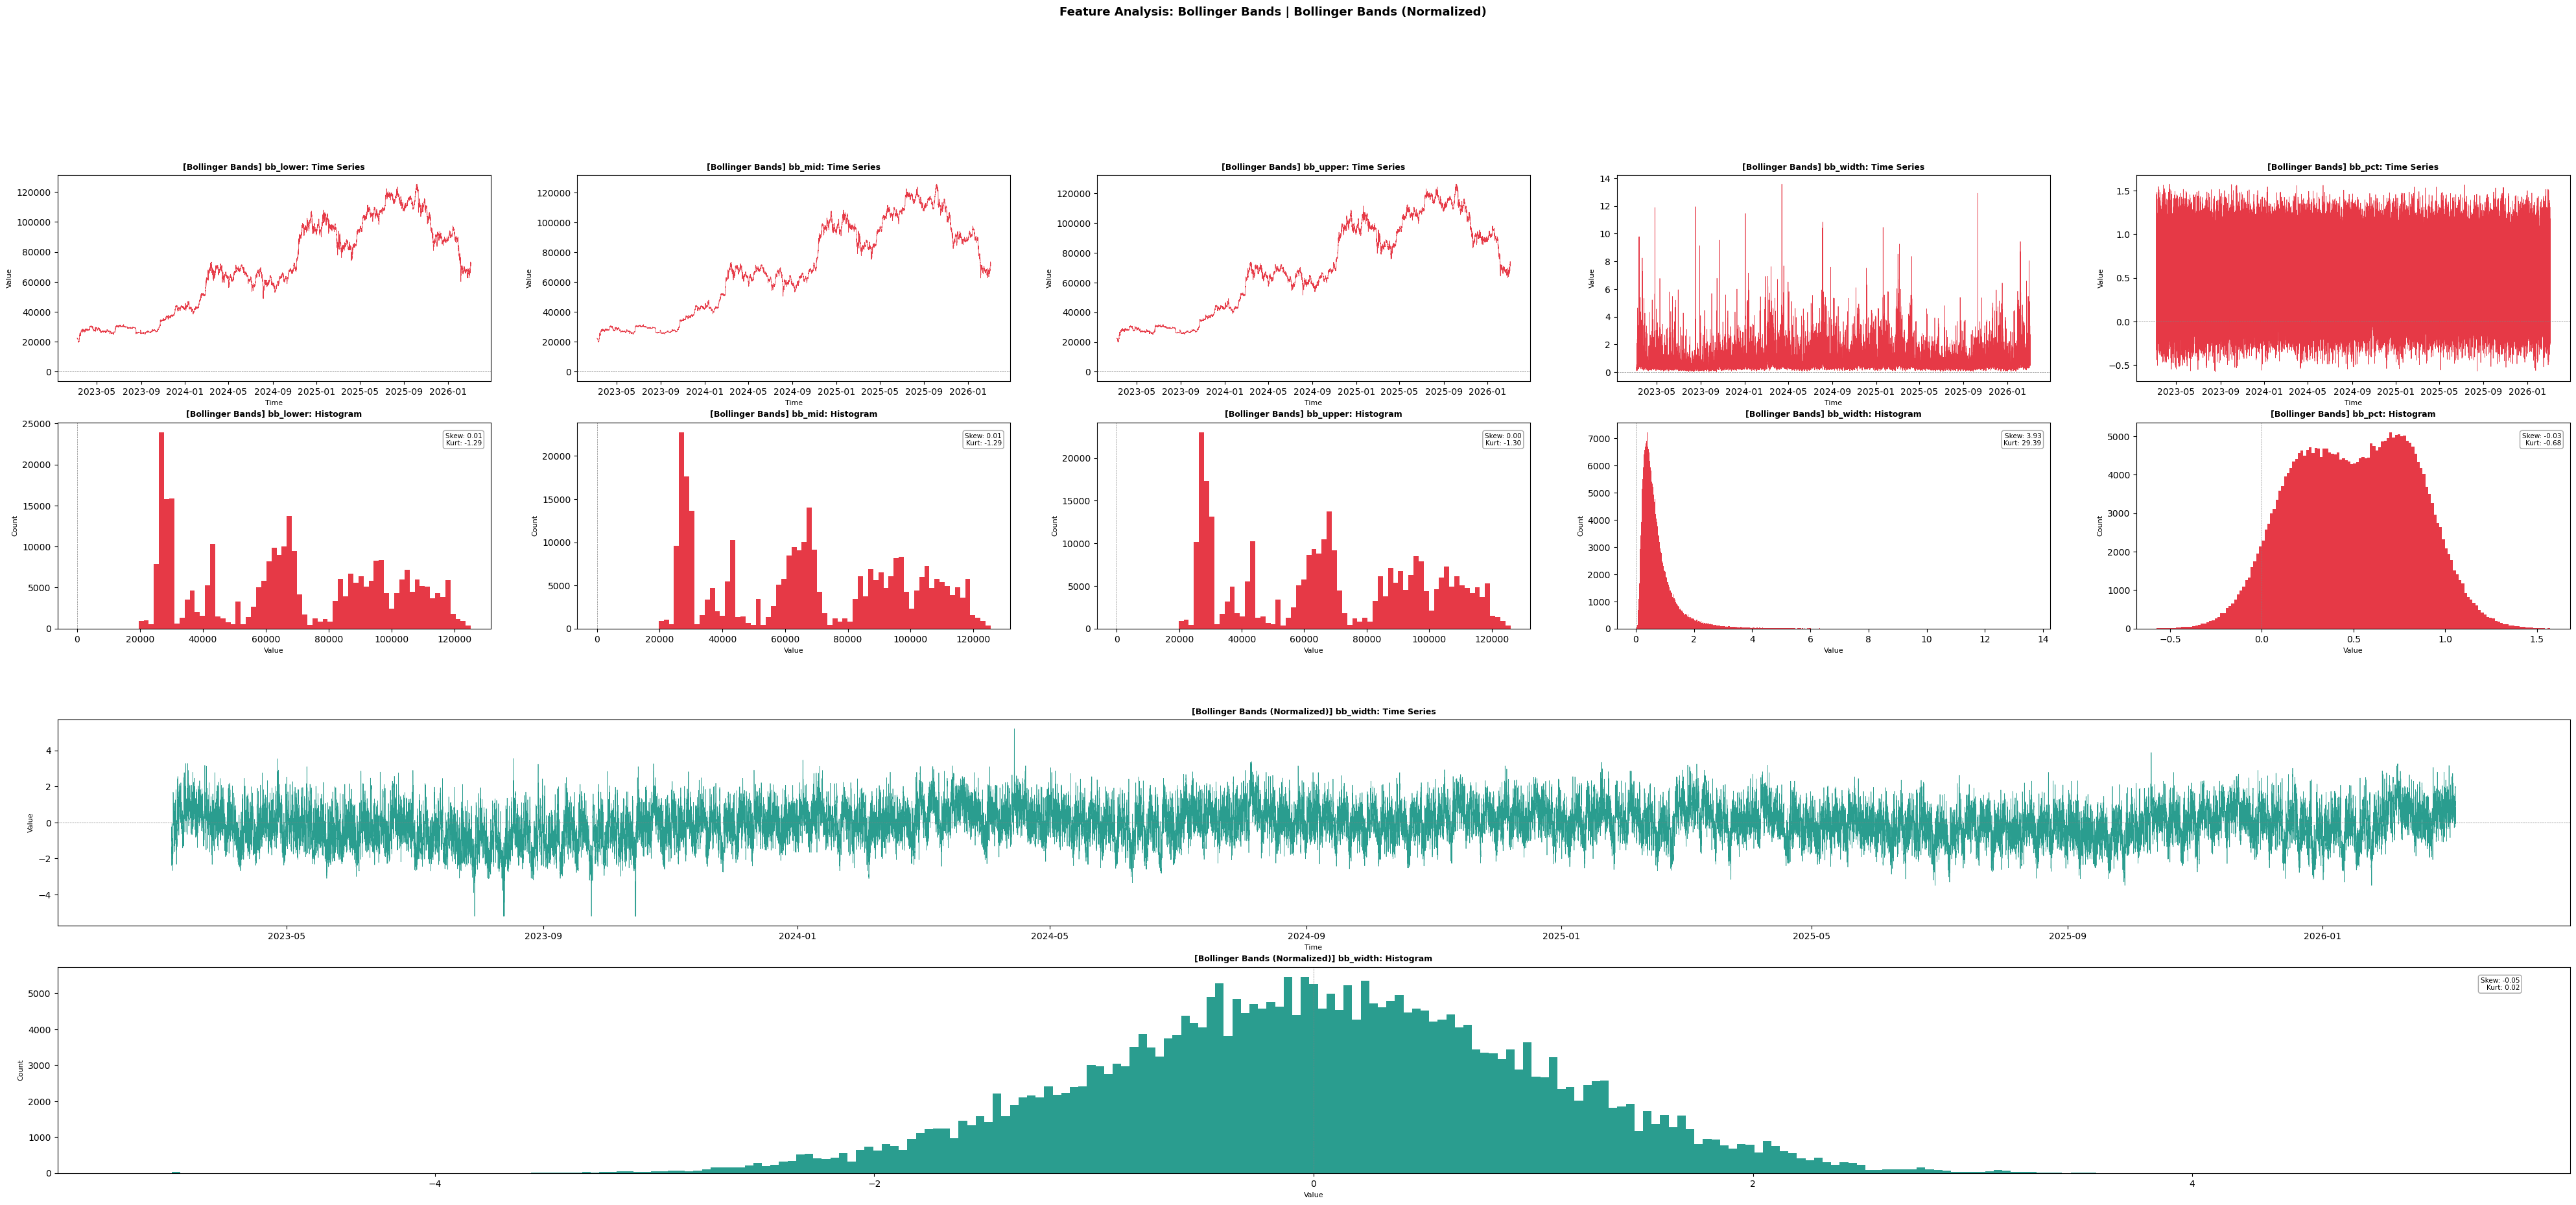

In [15]:
from framework.analysis.features.volatility import BollingerBands

bbands = BollingerBands()

bbands_raw = bbands.calculate(df)
bbands_raw.dropna(inplace=True)

bbands_norm = bbands.fit(bbands_raw).transform(bbands_raw)
bbands_norm.dropna(inplace=True)

plot_and_describe([
    (bbands_raw, "Bollinger Bands"),
    (bbands_norm, "Bollinger Bands (Normalized)"),
])

[Ulcer Index: ui]
count       315318.000000
mean             0.313581
std              0.323903
min              0.000000
25%              0.125508
50%              0.221191
75%              0.383231
max              6.473418
skew             4.035631
kurtosis        30.463031
dtype: float64

[Ulcer Index (Normalized): ui]
count       315318.000000
mean            -0.004075
std              1.003575
min             -5.199338
25%             -0.683463
50%              0.012427
75%              0.671888
max              5.199338
skew            -0.034119
kurtosis         0.065664
dtype: float64



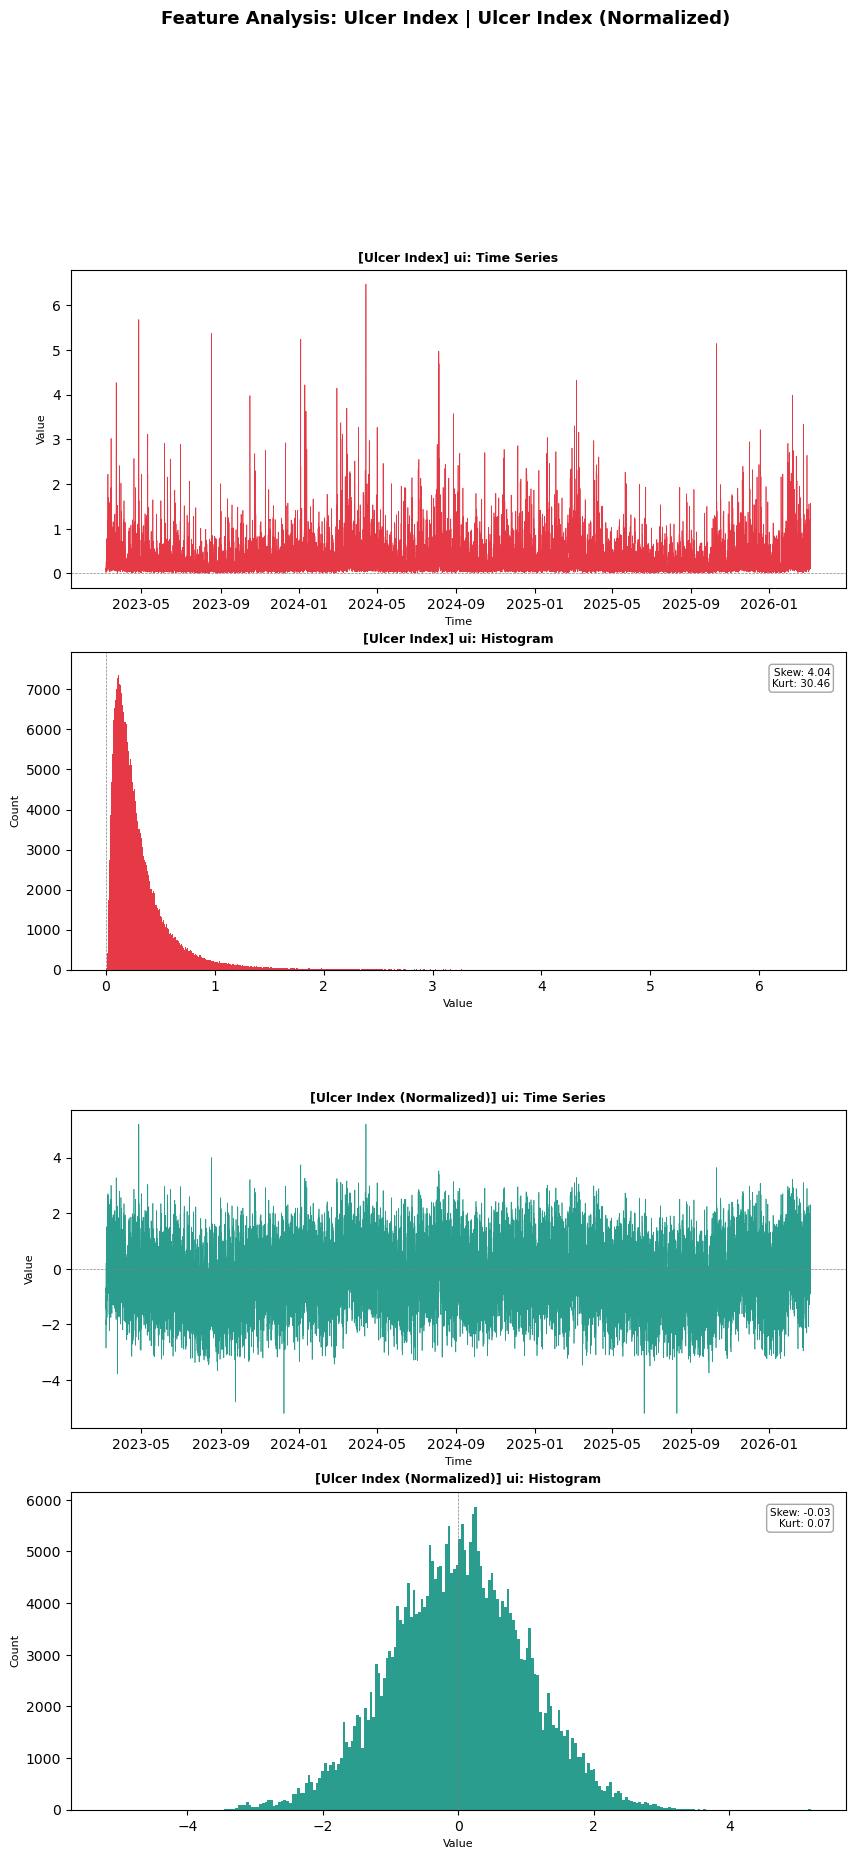

In [16]:
from framework.analysis.features.volatility import UlcerIndex

ui = UlcerIndex()

ui_raw = ui.calculate(df)
ui_raw.dropna(inplace=True)

ui_norm = ui.fit(ui_raw).transform(ui_raw)
ui_norm.dropna(inplace=True)

plot_and_describe([
    (ui_raw, "Ulcer Index"),
    (ui_norm, "Ulcer Index (Normalized)"),
])

[Chaikin Money Flow: cmf]
count       315325.000000
mean             0.012517
std              0.166019
min             -0.756104
25%             -0.098582
50%              0.012711
75%              0.123529
max              0.805719
skew             0.002380
kurtosis         0.090621
dtype: float64

[Chaikin Money Flow (Normalized): cmf]
count       315325.000000
mean             0.009334
std              0.999422
min             -5.199338
25%             -0.654708
50%              0.007688
75%              0.685023
max              5.199338
skew            -0.026475
kurtosis        -0.010970
dtype: float64



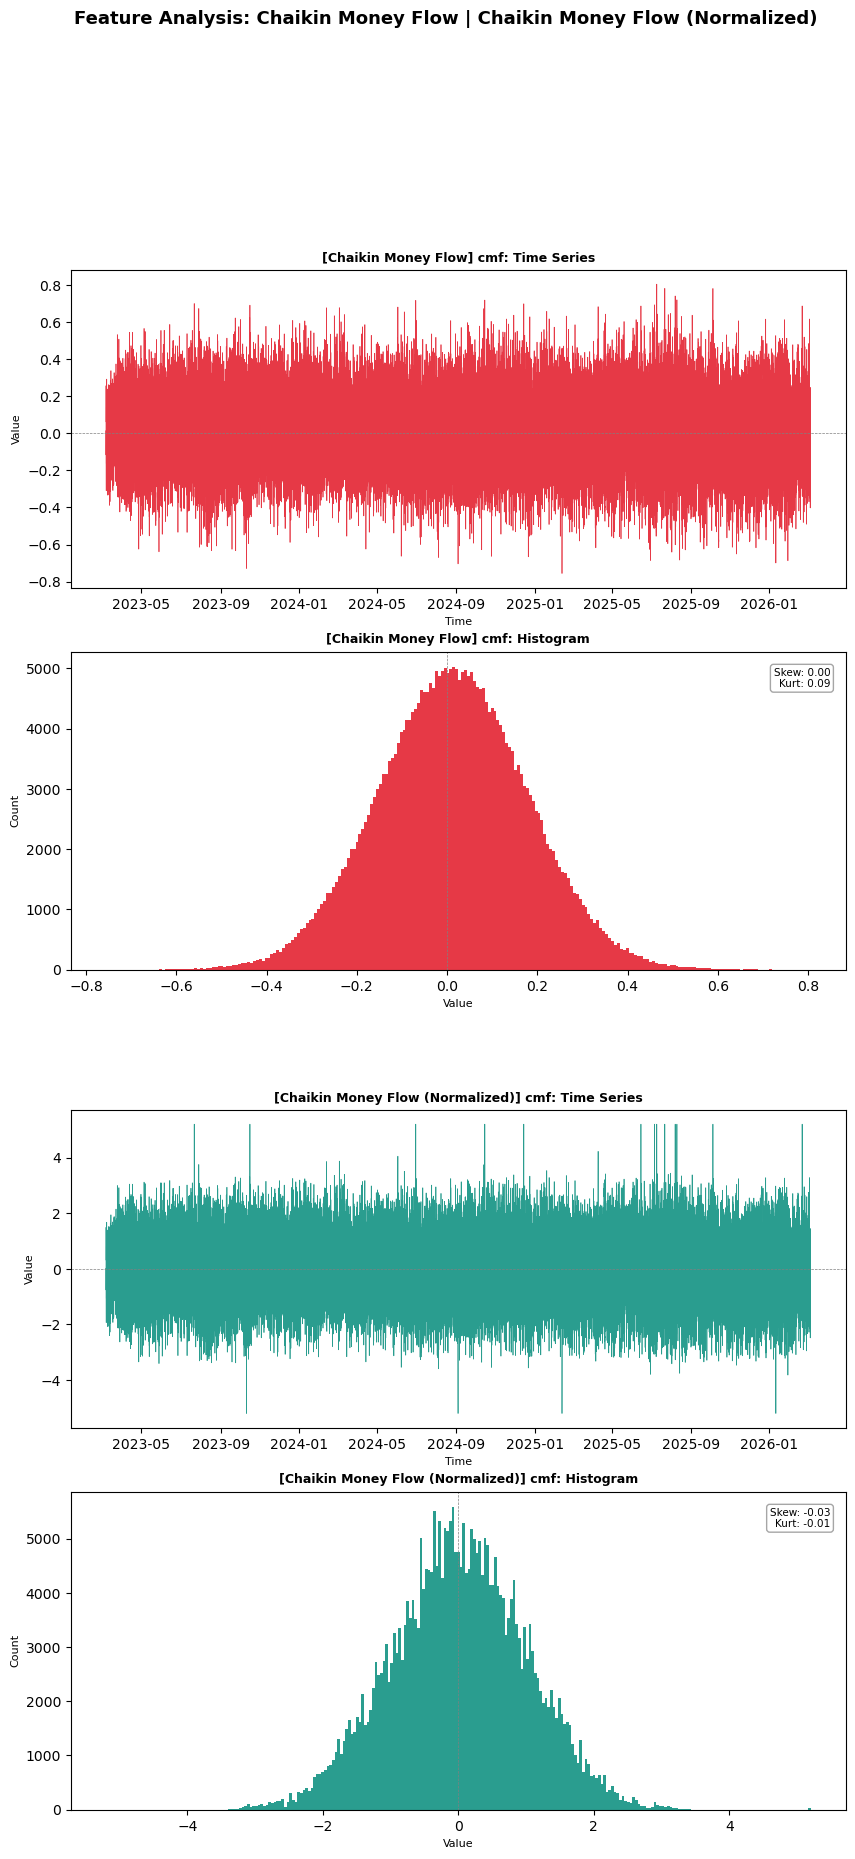

In [17]:
from framework.analysis.features.volume import ChaikinMoneyFlow

cmf = ChaikinMoneyFlow()

cmf_raw = cmf.calculate(df)
cmf_raw.dropna(inplace=True)

cmf_norm = cmf.fit(cmf_raw).transform(cmf_raw)
cmf_norm.dropna(inplace=True)

plot_and_describe([
    (cmf_raw, "Chaikin Money Flow"),
    (cmf_norm, "Chaikin Money Flow (Normalized)"),
])

[Volume Ratio: volume_ratio]
count       315344.000000
mean             1.029052
std              0.790878
min              0.000000
25%              0.574943
50%              0.820755
75%              1.211006
max             16.475681
skew             3.839863
kurtosis        27.343766
dtype: float64

[Volume Ratio (Normalized): volume_ratio]
count       315344.000000
mean             0.000353
std              0.995206
min             -5.199338
25%             -0.670290
50%              0.001164
75%              0.679021
max              5.199338
skew            -0.029810
kurtosis         0.132699
dtype: float64



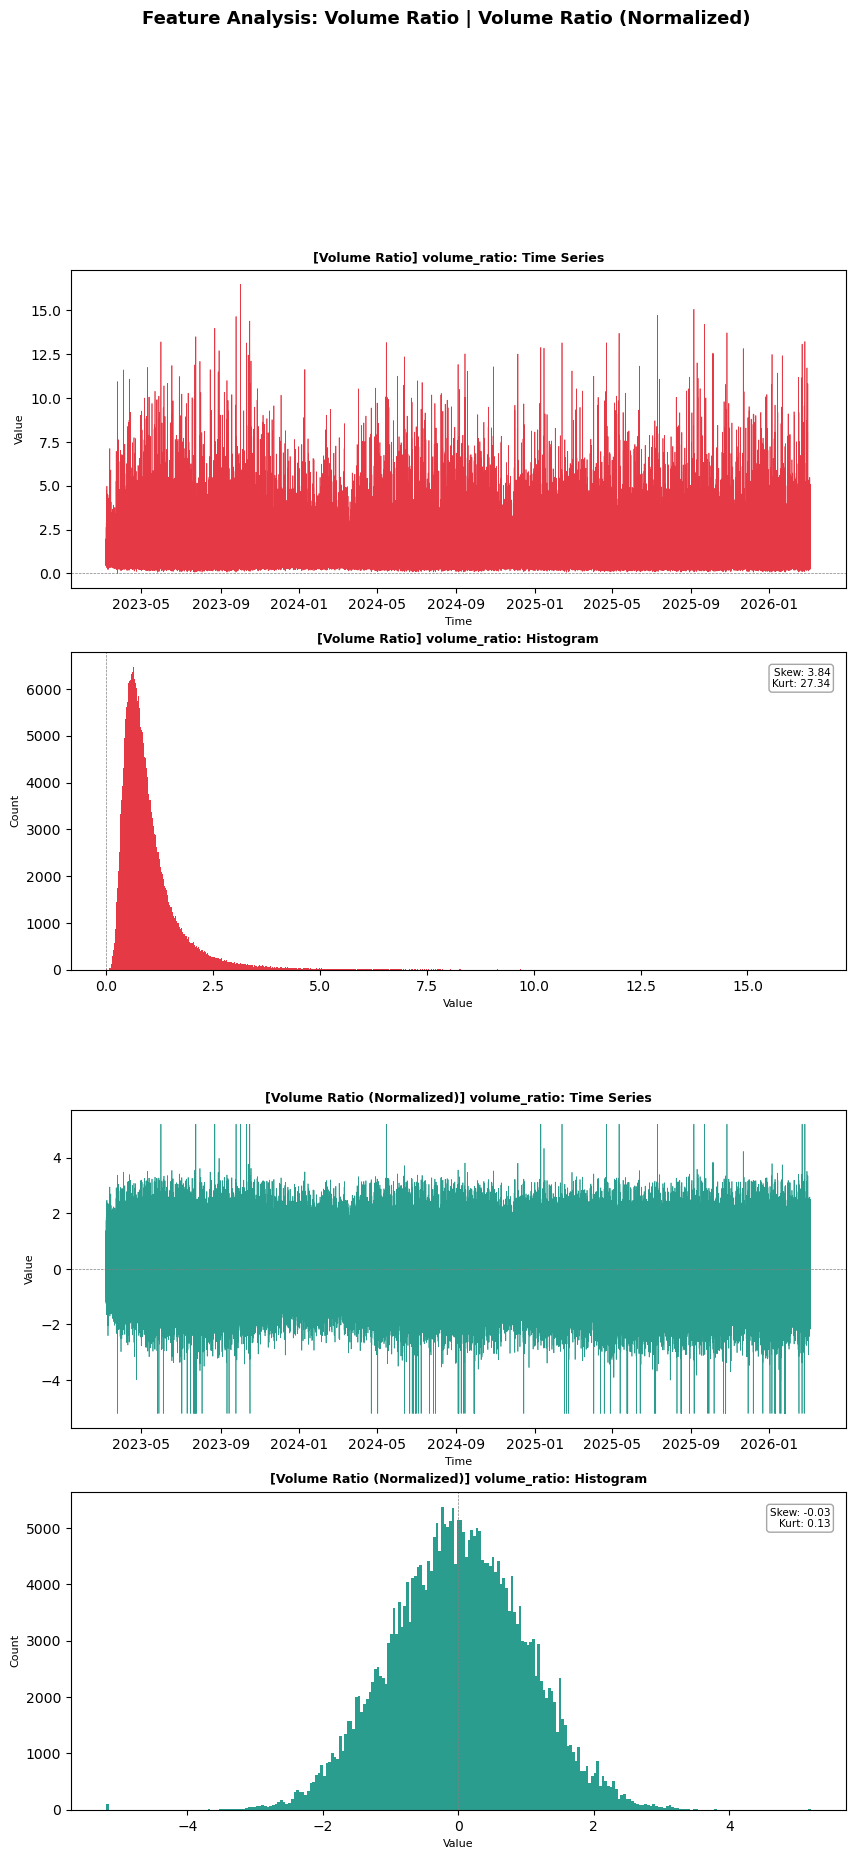

In [18]:
from framework.analysis.features.volume import VolumeRatio

vratio = VolumeRatio()

vratio_raw = vratio.calculate(df)
vratio_raw.dropna(inplace=True)

vratio_norm = vratio.fit(vratio_raw).transform(vratio_raw)
vratio_norm.dropna(inplace=True)

plot_and_describe([
    (vratio_raw, "Volume Ratio"),
    (vratio_norm, "Volume Ratio (Normalized)"),
])

[Money Flow Index: mfi]
count       3.153300e+05
mean        4.986487e+01
std         1.771798e+01
min        -2.760780e-12
25%         3.688387e+01
50%         4.975202e+01
75%         6.282132e+01
max         1.000000e+02
skew        1.437455e-02
kurtosis   -5.378918e-01
dtype: float64

[Money Flow Index (Normalized): mfi]
count       315330.000000
mean            -0.002703
std              0.354360
min             -1.000000
25%             -0.262323
50%             -0.004960
75%              0.256426
max              1.000000
skew             0.014375
kurtosis        -0.537892
dtype: float64



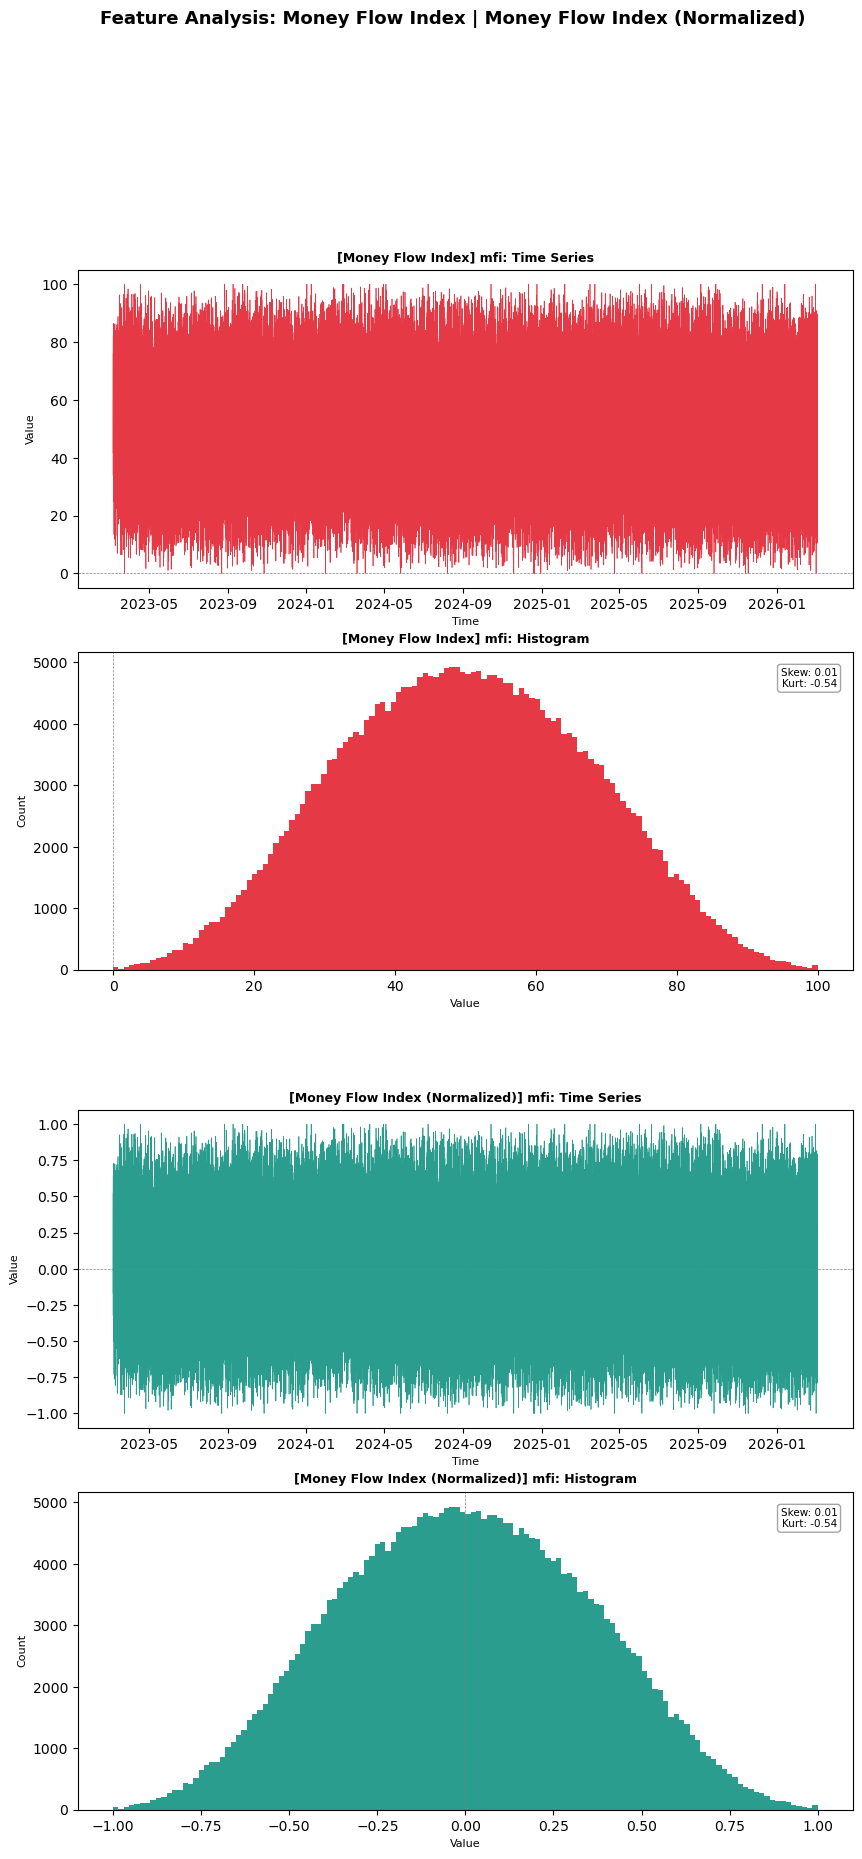

In [19]:
from framework.analysis.features.volume import MoneyFlowIndex

mfi = MoneyFlowIndex()

mfi_raw = mfi.calculate(df)
mfi_raw.dropna(inplace=True)

mfi_norm = mfi.fit(mfi_raw).transform(mfi_raw)
mfi_norm.dropna(inplace=True)

plot_and_describe([
    (mfi_raw, "Money Flow Index"),
    (mfi_norm, "Money Flow Index (Normalized)"),
])

In [20]:
plot_df = pd.concat([cs_norm, macd_norm, rsi_norm, sqz_norm, strend_norm, ema_norm, dd_norm, logret_norm, adx_norm, psar_norm, natr_norm, bbands_norm, ui_norm, cmf_norm, vratio_norm, mfi_norm], axis=1)
plot_df.dropna(inplace=True)

print(f"Number of features: {len(plot_df.columns)}")
print(f"Feature Set: {', '.join(plot_df.columns)}")

Number of features: 19
Feature Set: rel_body, upper_wick, lower_wick, macd_hist, rsi, sqz, sqz_on, st_dist, ema_spread, dd_pct, log_return, adx, psar_dist, natr, bb_width, ui, cmf, volume_ratio, mfi


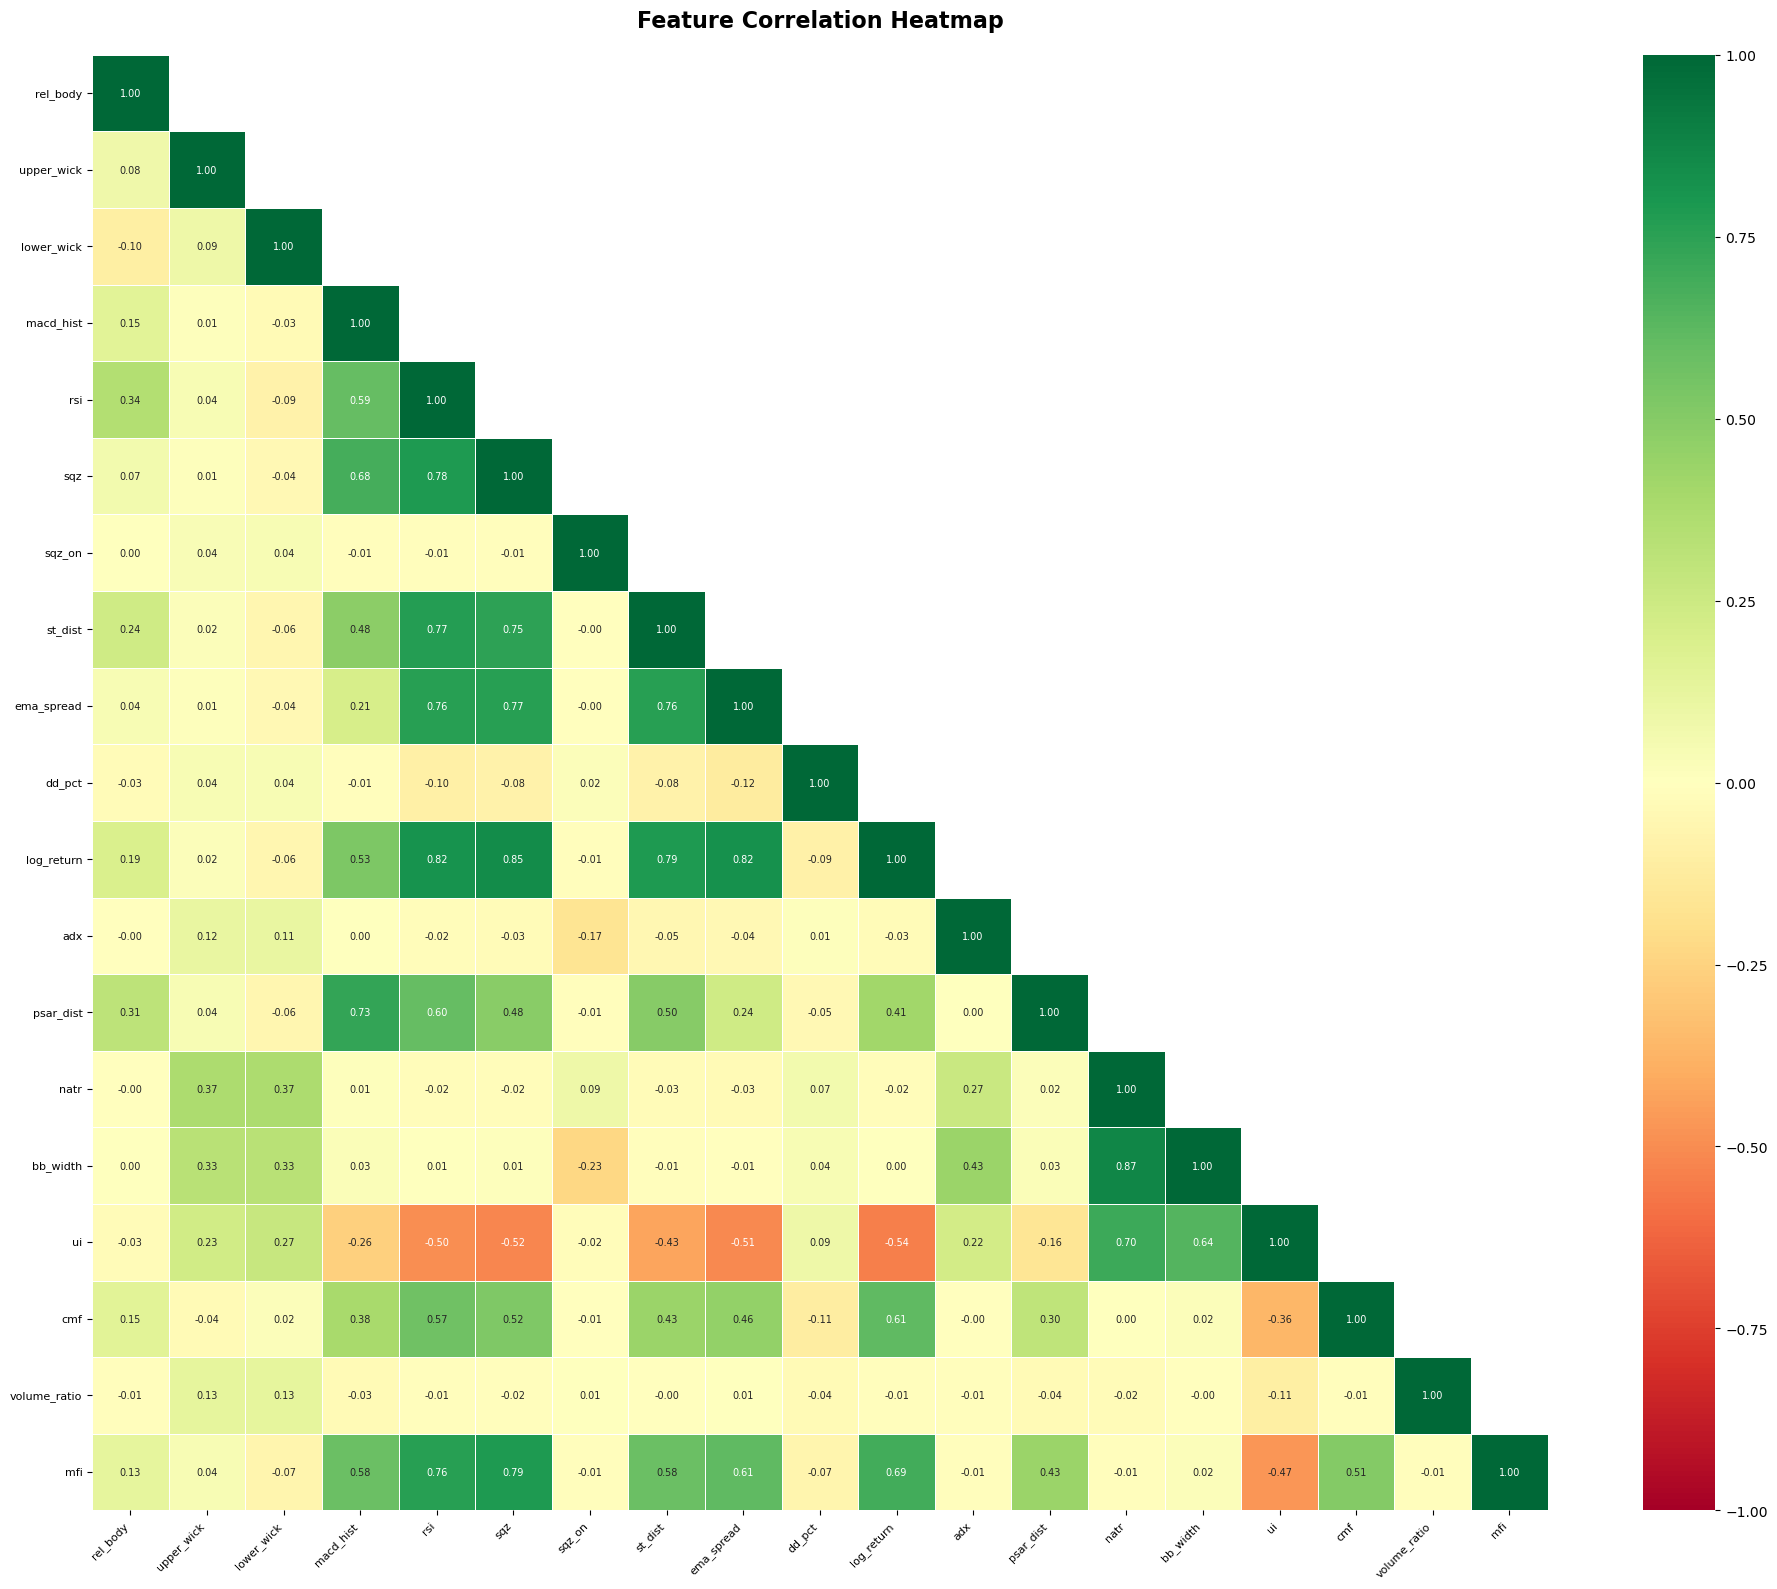

Found 1 correlated pairs (|corr| > 0.85):


,Feature A,Feature B,Correlation
0,natr,bb_width,0.870871


In [27]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = plot_df.corr(method="pearson")

# Mask the upper triangle (k=0 includes the diagonal, k=1 excludes it)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(20, 16))
sns.heatmap(
    corr_matrix,
    ax=ax,
    mask=mask,  # Hides upper triangle
    annot=True,  # Show numbers in each cell
    fmt=".2f",  # 2 decimal places
    cmap="RdYlGn",  # Red = negative, Yellow = neutral, Green = positive
    center=0,  # Anchor color scale at 0
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    annot_kws={"size": 7},
    square=True,
)
ax.set_title("Feature Correlation Heatmap", fontsize=16, fontweight="bold", pad=20)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

# Extract pairs with |correlation| > threshold (excluding self-correlation)
THRESHOLD = 0.85

high_corr_pairs = (
    corr_matrix.where(lambda df: (df.abs() >= THRESHOLD) & (df != 1.0))
    .stack()
    .reset_index()
    .rename(columns={"level_0": "Feature A", "level_1": "Feature B", 0: "Correlation"})
    .drop_duplicates(subset=["Correlation"])  # Remove duplicates (A-B and B-A)
    .sort_values("Correlation", key=abs, ascending=False)
)

print(f"Found {len(high_corr_pairs)} correlated pairs (|corr| > {THRESHOLD}):")
high_corr_pairs

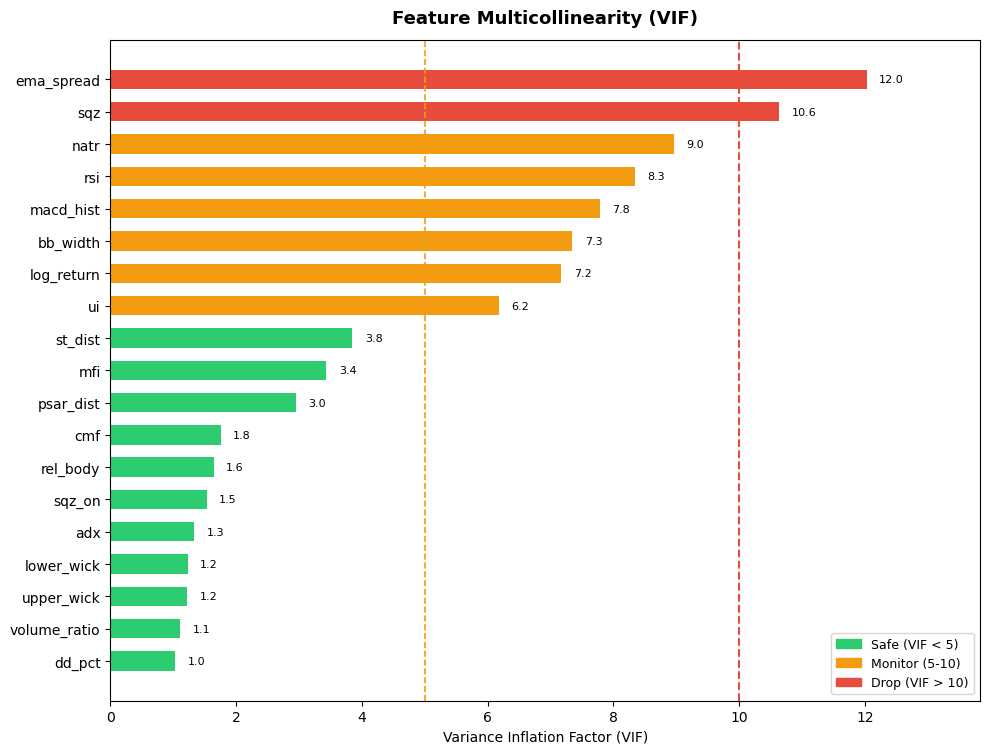

         feature        VIF
8     ema_spread  12.027122
5            sqz  10.635295
13          natr   8.964870
4            rsi   8.343000
3      macd_hist   7.784420
14      bb_width   7.349380
10    log_return   7.173853
15            ui   6.176169
7        st_dist   3.846116
18           mfi   3.433863
12     psar_dist   2.953195
16           cmf   1.754219
0       rel_body   1.642027
6         sqz_on   1.529602
11           adx   1.333367
2     lower_wick   1.230887
1     upper_wick   1.224456
17  volume_ratio   1.105707
9         dd_pct   1.032908


In [22]:
import matplotlib.patches as mpatches
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = plot_df.values
vif_data = pd.DataFrame({"feature": plot_df.columns, "VIF": [variance_inflation_factor(X, i) for i in range(X.shape[1])]}).sort_values("VIF", ascending=False)


fig, ax = plt.subplots(figsize=(10, len(vif_data) * 0.35 + 1))

colors = [
    "#e74c3c"
    if v > 10
    # Red — drop
    else "#f39c12"
    if v > 5
    # Orange — monitor
    else "#2ecc71"  # Green — safe
    for v in vif_data["VIF"]
]

bars = ax.barh(vif_data["feature"], vif_data["VIF"], color=colors, edgecolor="none", height=0.6)

ax.axvline(x=5, color="#f39c12", linestyle="--", linewidth=1.2, label="Monitor (VIF=5)")
ax.axvline(x=10, color="#e74c3c", linestyle="--", linewidth=1.5, label="Drop (VIF=10)")

for bar, val in zip(bars, vif_data["VIF"]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2, f"{val:.1f}", va="center", ha="left", fontsize=8)

ax.set_xlabel("Variance Inflation Factor (VIF)")
ax.set_title("Feature Multicollinearity (VIF)", fontsize=13, fontweight="bold", pad=12)
ax.invert_yaxis()

legend_patches = [
    mpatches.Patch(color="#2ecc71", label="Safe (VIF < 5)"),
    mpatches.Patch(color="#f39c12", label="Monitor (5-10)"),
    mpatches.Patch(color="#e74c3c", label="Drop (VIF > 10)"),
]
ax.legend(handles=legend_patches, loc="lower right", fontsize=9)
ax.set_xlim(0, vif_data["VIF"].max() * 1.15)

plt.tight_layout()
plt.show()


print(vif_data)

In [ ]:
from sklearn.feature_selection import mutual_info_regression

# Target: 1-candle forward log return
target = np.log(df["close"].shift(-1) / df["close"]).loc[plot_df.index]
clean = plot_df.join(target.rename("target")).dropna()

mi_scores = mutual_info_regression(
    clean[plot_df.columns],
    clean["target"],
    random_state=42,
)

mi_df = pd.DataFrame(
    {"feature": plot_df.columns, "MI": mi_scores},
).sort_values("MI", ascending=False)

fig, ax = plt.subplots(figsize=(10, len(mi_df) * 0.35 + 1))

# Normalize MI to [0, 1] for color mapping
mi_norm = mi_df["MI"] / mi_df["MI"].max()
colors = plt.cm.RdYlGn(mi_norm.values)

bars = ax.barh(mi_df["feature"], mi_df["MI"], color=colors, edgecolor="none", height=0.6)

# Mark the "near zero" threshold
zero_thresh = mi_df["MI"].max() * 0.05  # bottom 5% of max = effectively zero
ax.axvline(x=zero_thresh, color="#e74c3c", linestyle="--", linewidth=1.5, label=f"Near-zero threshold ({zero_thresh:.4f})")

for bar, val in zip(bars, mi_df["MI"]):
    ax.text(bar.get_width() + mi_df["MI"].max() * 0.01, bar.get_y() + bar.get_height() / 2, f"{val:.4f}", va="center", ha="left", fontsize=8)

ax.set_xlabel("Mutual Information Score")
ax.set_title("Feature Predictive Power (MI vs 1-step forward return)", fontsize=13, fontweight="bold", pad=12)
ax.invert_yaxis()
ax.set_xlim(0, mi_df["MI"].max() * 1.2)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(mi_df)